In [32]:
# TODO:
# - Meet betrouwbaarheid van de sensoren:
#   - Hoeveel metingen per dag?
#   - ..?

In [33]:
# Import neccesary libraries
from custom_functions.data_transformations import anonymize_location, resample
from custom_functions.visuals import sensor_visual
from custom_functions.powerpoint import make_powerpoint
import pandas as pd
import numpy as np
from datetime import datetime
import plotly.express as px
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
from scipy.stats import f_oneway

In [63]:
df = pd.read_excel('./data/prepped_sensor_data.xlsx')
df.head(5)

,locatie,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,datum,gem_meetwaarde,windsnelheid,temperatuur,zonneschijn_duur,neerslag_duur,neerslag,luchtdruk,bewolking,vochtigheid,verdamping
0,Vijf meilaan (2)_30,30 cm,0-1 jaar,Plantenvak,Zuid,bestrating,2023-07-05,33.196667,90,14.2,17,97,26.6,10074,8,87,14
1,Beethovenpark_30,30 cm,0-1 jaar,Plantenvak,Zuid,groen,2023-07-05,8.791000,90,14.2,17,97,26.6,10074,8,87,14
2,Boshuizerkade_30,30 cm,0-1 jaar,Plantenvak,Zuid,bebouwing,2023-07-05,8.728333,90,14.2,17,97,26.6,10074,8,87,14
3,Haven binnenstad_30,30 cm,> 1 jaar,Plant en boom,Midden,bebouwing,2023-07-05,13.133333,90,14.2,17,97,26.6,10074,8,87,14
4,Tasmanpark (1)_15,15 cm,> 1 jaar,Plant en boom,Binnenstad,groen,2023-07-05,8.186667,90,14.2,17,97,26.6,10074,8,87,14


In [64]:
df['datum'].max()

Timestamp('2025-04-21 00:00:00')

In [35]:
# exclude_location_lst = ['Zeemanlaan_15','Park hooghkamer_30','Stevenspark_30','Lammenschansweg_30','Polderpark_30']
# start_date = '2022-08-01'

# df = df[(~df['locatie'].isin(exclude_location_lst)) & (df['datum'] >= start_date)]

# Data Analyse

## 1 Initialiseer dataset en parameters

### 1.1 Toevoegen van berekende kolommen
sensorwaarde (s) = gemiddelde meetwaarde van de sensor gemeten over een gehele dag 00:00 - 23.59
neerslag (n) = Etmaalsom van de neerslag (in mm) (-1 voor <0.05 mm)
temperatuur (T) = 

- **s_prev**: is de sensorwaarde van de vorige dag
- **s_prev_diff**: is het verschil tussen de sensorwaarde van de vorige dag en huidige dag ($ = \text{huidige dag} - \text{vorige dag} $)
- **s_prev_diff_2**: is het verschil tussen de sensorwaarde van eergister en huidige dag ($ = \text{huidige dag} - \text{twee dagen geleden} $)
- **s_prev_diff_perc**: is het percentuele verschil tussen de sensorwaarde van de vorige dag en huidige dag $ \frac{{\text{huidige dag} - \text{vorige dag}}}{{\text{vorige dag}}} $
- **s_norm**: is de genormaliseerde sensorwaarde obv mean en std. de genormaliseerde waarde (ook wel z-score genoemd) geeft aan hoeveel standaarddeviaties een bepaalde observatie afwijkt van het gemiddelde van een groep. Hiermee kun je de onderliggende verdeling van elke groep standariseren en vergelijken. Formule: $ X_{\text{nieuw}} = \frac{(X - \text{gemiddelde})}{\text{standaarddeviatie}} $
- **s_min_max**: is de genormaliseerde sensorwaarde obv min- en maxwaarde. Dit is een herschaling van de sensorwaarde, de maximale waarde krijgt waarde 1, de minimale waarde krijgt waarde 0. Formule: $ X_{\text{nieuw}} = \frac{(X - \text{Min})}{(\text{Max} - \text{Min})} $
- **s_min_max_prev**: is de genormaliseerde s_prev_diff obv min- en maxwaarde (zie s_min_max).
- **s_min_max_prev_2**: is de genormaliseerde s_prev_diff_2 obv min- en maxwaarde (zie s_min_max).
- **s_increase**: is TRUE wanneer s > s_prev, FALSE anders
- **n_prev**: is de neerslag van vorige dag
- **n_prev 2**: is de neerslag van twee dagen geleden
- **n_cum**: cummulatieve neerslag van huidige dag en de vorige dag
- **n_cum_2**: cummulatieve neerslag van huidige dag, de vorige dag en twee dagen geleden
- **T_mean**: gemiddelde Etmaalgemiddelde temperatuur in graden celcius van huidige dag en vorige dag
- **T_mean_2**: gemiddelde Etmaalgemiddelde temperatuur in graden celcius van huidige dag, vorige dag en twee dagen geleden

In [36]:
# Toevoegen van berekende kolommen

# Sort by date and location
df = df.sort_values(['locatie', 'datum'])

# maak extra kolommen aan om code leesbaarder te maken
df['s'] = df['gem_meetwaarde']
df['n'] = df['neerslag']
df['T'] = df['temperatuur']

# Bereken enkele measures
df['s_prev'] = df.groupby('locatie')['s'].shift(1)
df['s_prev_diff'] = df.groupby('locatie')['s'].diff(1)
df['s_prev_diff_2'] = df.groupby('locatie')['s'].diff(2)
df['s_prev_diff_perc'] = df.groupby(
    'locatie')['s'].pct_change()
df['s_norm'] = df.groupby(
    'locatie')['s'].transform(lambda x: (x - x.mean()) / x.std())
df['s_min_max'] = df.groupby('locatie')['s'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()))
df['s_min_max_prev'] = df.groupby('locatie')[
    's_prev_diff'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
df['s_min_max_prev_2'] = df.groupby('locatie')[
    's_prev_diff_2'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
df['s_increase'] = df['s'] > df['s_prev']

df['n_prev'] = df.groupby('locatie')['n'].shift(1)
df['n_prev_2'] = df.groupby('locatie')['n'].shift(2)

df['n_cum'] = df['n'] + df['n_prev']
df['n_cum_2'] = df['n'] + df['n_prev'] + df['n_prev_2']

df['T_mean'] = df.groupby('locatie')['T'].transform(lambda x: x.rolling(window=2).mean())
df['T_mean_2'] = df.groupby('locatie')['T'].transform(lambda x: x.rolling(window=3).mean())

df.head(5)

,locatie,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,datum,gem_meetwaarde,windsnelheid,temperatuur,...,s_min_max,s_min_max_prev,s_min_max_prev_2,s_increase,n_prev,n_prev_2,n_cum,n_cum_2,T_mean,T_mean_2
410,Arendshorst_30,30 cm,> 1 jaar,Boom,Noord,groen,2023-08-03,10.470000,60,17.2,...,0.877934,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
427,Arendshorst_30,30 cm,> 1 jaar,Boom,Noord,groen,2023-08-04,9.085000,39,16.8,...,0.661189,0.045754,NaN,False,1.3,NaN,2.8,NaN,17.00,NaN
444,Arendshorst_30,30 cm,> 1 jaar,Boom,Noord,groen,2023-08-05,8.647500,45,15.7,...,0.592723,0.215760,0.052047,False,1.5,1.3,13.0,14.3,16.25,16.566667
461,Arendshorst_30,30 cm,> 1 jaar,Boom,Noord,groen,2023-08-06,9.753333,65,14.9,...,0.765780,0.492673,0.433346,True,11.5,1.5,44.0,45.5,15.30,15.800000
477,Arendshorst_30,30 cm,> 1 jaar,Boom,Noord,groen,2023-08-07,9.460000,75,16.0,...,0.719875,0.241627,0.455415,False,32.5,11.5,34.4,45.9,15.45,15.533333


In [37]:
# df.to_excel('./dataframe.xlsx')

# Opschonen data

'Beethovenpark_15'allen na 8 april 2024 uit het dataframe halen  
‘Beethovenpark_30’ helemaal uit dataframe verwijderen  
'Beuk vismarkt_binnen_30' de periode van 22 april 2024 tot en met 8 juli 2024 uit dataframe verwijderen  
'Beuk vismarkt_buiten_30' helemaal uit dataframe verwijderen  
'Haven binnenstad_15' opsplitsen in ‘Haven binnenstad_15 (eerste plaatsing)’ en ‘Haven binnenstad_15 (herplaatsing)’.  
De periode van de eerste plaatsing is van begin tot en met 5 april 2024. De periode van de herplaatsing is vanaf 17 mei 2024 tot eind.  
‘Haven binnenstad_30’ uit dataframe verwijderen  
'Jacob van Campenlaan_15' de periode van 19 febr 2024 tot en met 17 mei 2024 uit dataframe verwijderen  
'Langegracht Politie_30' uit dataframe verwijderen  
'Tasmanpark (2)_15' periode van 5 febr 2024 tot en met 19 mei 2024 uit dataframe verwijderen  
'Vijf meilaan (1)_15' periode na 8 april 2024 verwijderen  
'Vijf meilaan (2)_30' periode na 23 december 2023 verwijderen  
'Beuk vismarkt_binnen_30' opsplitsen van begin tot 20 april 2024 en van 11 juli 2024 tot eind  
'Jacob van Campenlaan_15' opsplitsen van begin tot 17 februari 2024 en van 21 mei 2024 tot eind  
'Tasmanpark (2)_15' opsplitsen van begin tot 3 februari 2024 en van 21 mei 2024 tot eind


In [38]:
# Convert the 'datum' column to datetime format for easier date-based filtering
df['datum'] = pd.to_datetime(df['datum'], errors='coerce')

# Apply the specified cleaning operations

# Remove records for 'Beethovenpark_15' after April 8, 2024
df = df[~((df['locatie'] == 'Beethovenpark_15') & (df['datum'] > '2024-04-08'))]

# Remove all records for 'Beethovenpark_30'
df = df[df['locatie'] != 'Beethovenpark_30']

# Remove records for 'Beuk vismarkt_binnen_30' from April 22, 2024 to July 8, 2024
df = df[~((df['locatie'] == 'Beuk vismarkt_binnen_30') & 
           (df['datum'] >= '2024-04-22') & (df['datum'] <= '2024-07-08'))]

# Adjust the filtering to exclude multiple 'locatie' values in one step
excluded_locations = ['Zeemanlaan_15', 'Park hooghkamer_30', 'Stevenspark_30', 
                      'Lammenschansweg_30', 'Polderpark_30', 'Beuk vismarkt_buiten_30']

# Remove all records for specified locations
df = df[~df['locatie'].isin(excluded_locations)]

# Split 'Haven binnenstad_15' into two separate entries based on the date ranges
first_place = df[(df['locatie'] == 'Haven binnenstad_15') & (df['datum'] <= '2024-04-05')].copy()
first_place['locatie'] = 'Haven binnenstad_15 (eerste plaatsing)'

replaced_place = df[(df['locatie'] == 'Haven binnenstad_15') & (df['datum'] >= '2024-05-17')].copy()
replaced_place['locatie'] = 'Haven binnenstad_15 (herplaatsing)'

# Remove original 'Haven binnenstad_15' records and add the modified ones
df = df[df['locatie'] != 'Haven binnenstad_15']
df = pd.concat([df, first_place, replaced_place])

# Remove all records for 'Haven binnenstad_30'
df = df[df['locatie'] != 'Haven binnenstad_30']

# Remove records for 'Jacob van Campenlaan_15' from February 19, 2024 to May 17, 2024
df = df[~((df['locatie'] == 'Jacob van Campenlaan_15') & 
           (df['datum'] >= '2024-02-19') & (df['datum'] <= '2024-05-17'))]

# Remove all records for 'Langegracht Politie_30'
df = df[df['locatie'] != 'Langegracht Politie_30']

# Remove records for 'Tasmanpark (2)_15' from February 5, 2024 to May 19, 2024
df = df[~((df['locatie'] == 'Tasmanpark (2)_15') & 
           (df['datum'] >= '2024-02-05') & (df['datum'] <= '2024-05-19'))]

# Remove records for 'Vijf meilaan (1)_15' after April 8, 2024
df = df[~((df['locatie'] == 'Vijf meilaan (1)_15') & (df['datum'] > '2024-04-08'))]

# Remove records for 'Vijf meilaan (2)_30' after December 23, 2023
df = df[~((df['locatie'] == 'Vijf meilaan (2)_30') & (df['datum'] > '2023-12-23'))]

# Split 'Beuk vismarkt_binnen_30' into two separate entries based on the date ranges
beuk_first_place = df[(df['locatie'] == 'Beuk vismarkt_binnen_30') & (df['datum'] <= '2024-04-20')].copy()
beuk_first_place['locatie'] = 'Beuk vismarkt_binnen_30 (eerste plaatsing)'

beuk_replaced_place = df[(df['locatie'] == 'Beuk vismarkt_binnen_30') & (df['datum'] >= '2024-07-11')].copy()
beuk_replaced_place['locatie'] = 'Beuk vismarkt_binnen_30 (herplaatsing)'

# Split 'Jacob van Campenlaan_15' into two separate entries based on the date ranges
jacob_first_place = df[(df['locatie'] == 'Jacob van Campenlaan_15') & (df['datum'] <= '2024-02-17')].copy()
jacob_first_place['locatie'] = 'Jacob van Campenlaan_15 (eerste plaatsing)'

jacob_replaced_place = df[(df['locatie'] == 'Jacob van Campenlaan_15') & (df['datum'] >= '2024-05-21')].copy()
jacob_replaced_place['locatie'] = 'Jacob van Campenlaan_15 (herplaatsing)'

# Split 'Tasmanpark (2)_15' into two separate entries based on the date ranges
tasman_first_place = df[(df['locatie'] == 'Tasmanpark (2)_15') & (df['datum'] <= '2024-02-03')].copy()
tasman_first_place['locatie'] = 'Tasmanpark (2)_15 (eerste plaatsing)'

tasman_replaced_place = df[(df['locatie'] == 'Tasmanpark (2)_15') & (df['datum'] >= '2024-05-21')].copy()
tasman_replaced_place['locatie'] = 'Tasmanpark (2)_15 (herplaatsing)'

# Remove original records and add the modified ones
df = df[~df['locatie'].isin(['Beuk vismarkt_binnen_30', 'Jacob van Campenlaan_15', 'Tasmanpark (2)_15'])]
df = pd.concat([df, beuk_first_place, beuk_replaced_place, jacob_first_place, jacob_replaced_place, tasman_first_place, tasman_replaced_place])

# Ensure the dataset is reset
df.reset_index(drop=True, inplace=True)

# df.to_excel('dataframe.xlsx')

df

,locatie,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,datum,gem_meetwaarde,windsnelheid,temperatuur,...,s_min_max,s_min_max_prev,s_min_max_prev_2,s_increase,n_prev,n_prev_2,n_cum,n_cum_2,T_mean,T_mean_2
0,Arendshorst_30,30 cm,> 1 jaar,Boom,Noord,groen,2023-08-03,10.470000,60,17.2,...,0.877934,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
1,Arendshorst_30,30 cm,> 1 jaar,Boom,Noord,groen,2023-08-04,9.085000,39,16.8,...,0.661189,0.045754,NaN,False,1.3,NaN,2.8,NaN,17.00,NaN
2,Arendshorst_30,30 cm,> 1 jaar,Boom,Noord,groen,2023-08-05,8.647500,45,15.7,...,0.592723,0.215760,0.052047,False,1.5,1.3,13.0,14.3,16.25,16.566667
3,Arendshorst_30,30 cm,> 1 jaar,Boom,Noord,groen,2023-08-06,9.753333,65,14.9,...,0.765780,0.492673,0.433346,True,11.5,1.5,44.0,45.5,15.30,15.800000
4,Arendshorst_30,30 cm,> 1 jaar,Boom,Noord,groen,2023-08-07,9.460000,75,16.0,...,0.719875,0.241627,0.455415,False,32.5,11.5,34.4,45.9,15.45,15.533333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10230,Tasmanpark (2)_15 (herplaatsing),15 cm,> 1 jaar,Plantenvak,Binnenstad,groen,2024-08-22,6.570000,82,19.2,...,0.284792,0.574679,0.573201,True,0.1,15.5,0.1,15.6,17.90,17.866667
10231,Tasmanpark (2)_15 (herplaatsing),15 cm,> 1 jaar,Plantenvak,Binnenstad,groen,2024-08-23,6.581667,76,19.0,...,0.285453,0.574614,0.575129,True,0.0,0.1,2.3,2.4,19.10,18.266667
10232,Tasmanpark (2)_15 (herplaatsing),15 cm,> 1 jaar,Plantenvak,Binnenstad,groen,2024-08-24,6.566667,54,18.2,...,0.284603,0.573586,0.574036,False,2.3,0.0,14.7,14.7,18.60,18.800000
10233,Tasmanpark (2)_15 (herplaatsing),15 cm,> 1 jaar,Plantenvak,Binnenstad,groen,2024-08-25,6.560000,61,16.6,...,0.284226,0.573907,0.573329,False,12.4,2.3,15.5,17.8,17.40,17.933333


# sensor statistieken

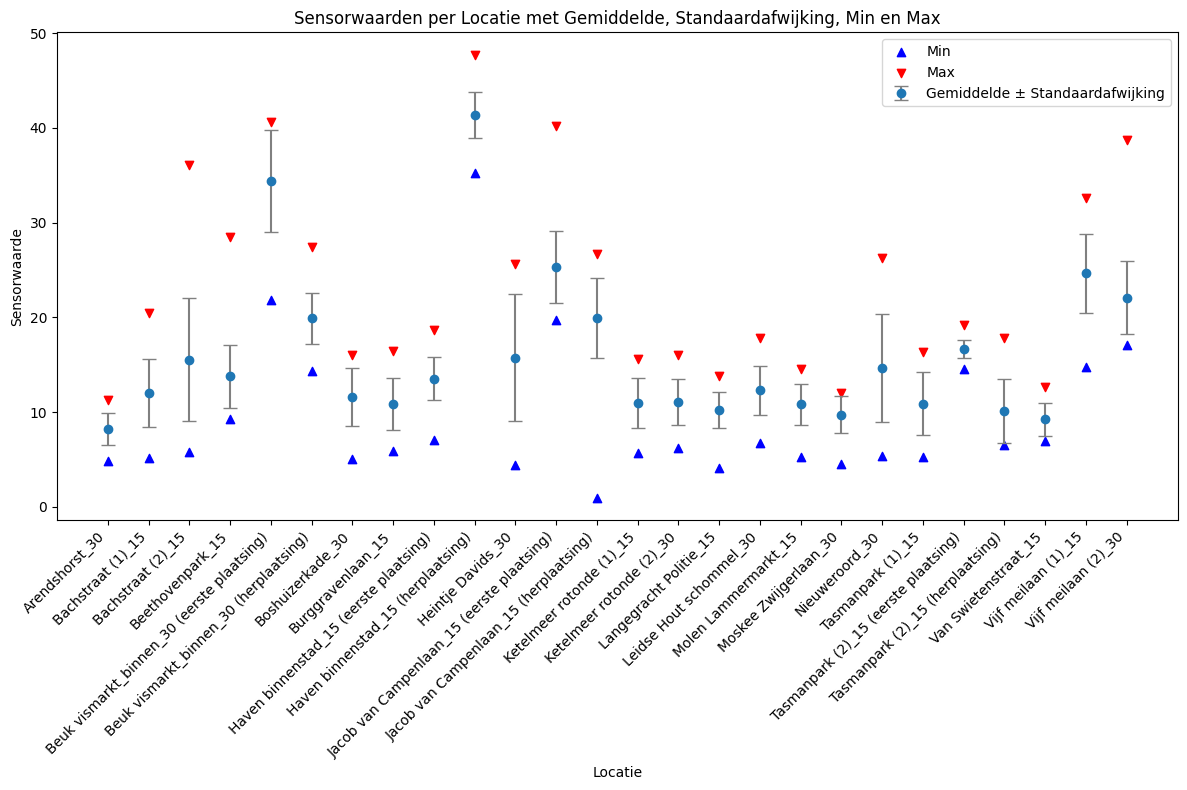

In [39]:
# Bereken statistieken (mean, std, min, max) voor de sensorwaarde 's' per locatie
location_stats = df.groupby('locatie')['s'].agg(['mean', 'std', 'min', 'max']).reset_index()

# Maak de plot
plt.figure(figsize=(12, 8))
plt.errorbar(location_stats['locatie'], 
             location_stats['mean'], 
             yerr=location_stats['std'], 
             fmt='o', ecolor='gray', capsize=5, label='Gemiddelde ± Standaardafwijking')

# Voeg min en max toe als extra markers
plt.scatter(location_stats['locatie'], location_stats['min'], color='blue', marker='^', label='Min')
plt.scatter(location_stats['locatie'], location_stats['max'], color='red', marker='v', label='Max')

# Stijl en labels toevoegen voor duidelijkheid
plt.xticks(rotation=45, ha='right')  # Rotatie aangepast naar 45 graden en uitlijning naar rechts
plt.title("Sensorwaarden per Locatie met Gemiddelde, Standaardafwijking, Min en Max")
plt.xlabel("Locatie")
plt.ylabel("Sensorwaarde")
plt.legend()
plt.tight_layout()

# Toon de plot
plt.show()


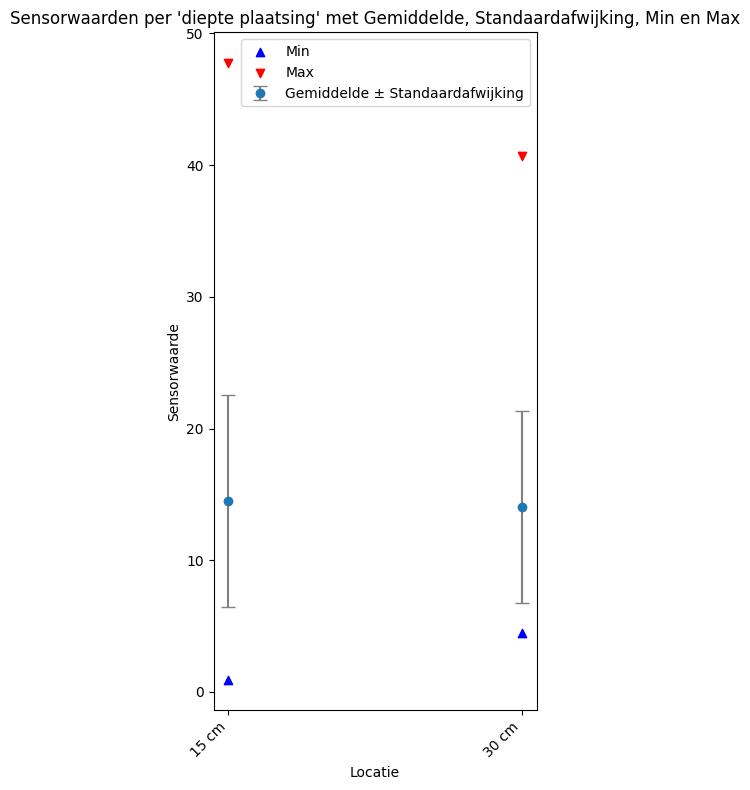

In [40]:
# Bereken statistieken (mean, std, min, max) voor de sensorwaarde 's' per locatie
location_stats = df.groupby('diepte_plaatsing')['s'].agg(['mean', 'std', 'min', 'max']).reset_index()

# Maak de plot
plt.figure(figsize=(4, 8))
plt.errorbar(location_stats['diepte_plaatsing'], 
             location_stats['mean'], 
             yerr=location_stats['std'], 
             fmt='o', ecolor='gray', capsize=5, label='Gemiddelde ± Standaardafwijking')

# Voeg min en max toe als extra markers
plt.scatter(location_stats['diepte_plaatsing'], location_stats['min'], color='blue', marker='^', label='Min')
plt.scatter(location_stats['diepte_plaatsing'], location_stats['max'], color='red', marker='v', label='Max')

# Stijl en labels toevoegen voor duidelijkheid
plt.xticks(rotation=45, ha='right')  # Rotatie aangepast naar 45 graden en uitlijning naar rechts
plt.title("Sensorwaarden per \'diepte plaatsing\' met Gemiddelde, Standaardafwijking, Min en Max")
plt.xlabel("Locatie")
plt.ylabel("Sensorwaarde")
plt.legend()
plt.tight_layout()

# Toon de plot
plt.show()

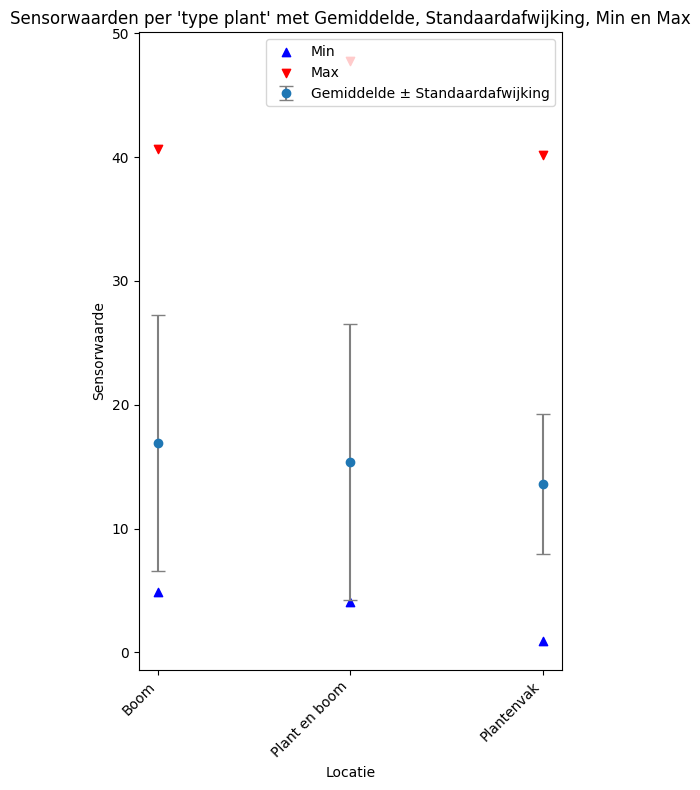

In [41]:
# Bereken statistieken (mean, std, min, max) voor de sensorwaarde 's' per locatie
filtered_df = df[df['soort_plant'] != 'Bosplantsoen']
location_stats = filtered_df.groupby('soort_plant')['s'].agg(['mean', 'std', 'min', 'max']).reset_index()

# Maak de plot
plt.figure(figsize=(5, 8))
plt.errorbar(location_stats['soort_plant'], 
             location_stats['mean'], 
             yerr=location_stats['std'], 
             fmt='o', ecolor='gray', capsize=5, label='Gemiddelde ± Standaardafwijking')

# Voeg min en max toe als extra markers
plt.scatter(location_stats['soort_plant'], location_stats['min'], color='blue', marker='^', label='Min')
plt.scatter(location_stats['soort_plant'], location_stats['max'], color='red', marker='v', label='Max')

# Stijl en labels toevoegen voor duidelijkheid
plt.xticks(rotation=45, ha='right')  # Rotatie aangepast naar 45 graden en uitlijning naar rechts
plt.title("Sensorwaarden per \'type plant\' met Gemiddelde, Standaardafwijking, Min en Max")
plt.xlabel("Locatie")
plt.ylabel("Sensorwaarde")
plt.legend()
plt.tight_layout()

# Toon de plot
plt.show()

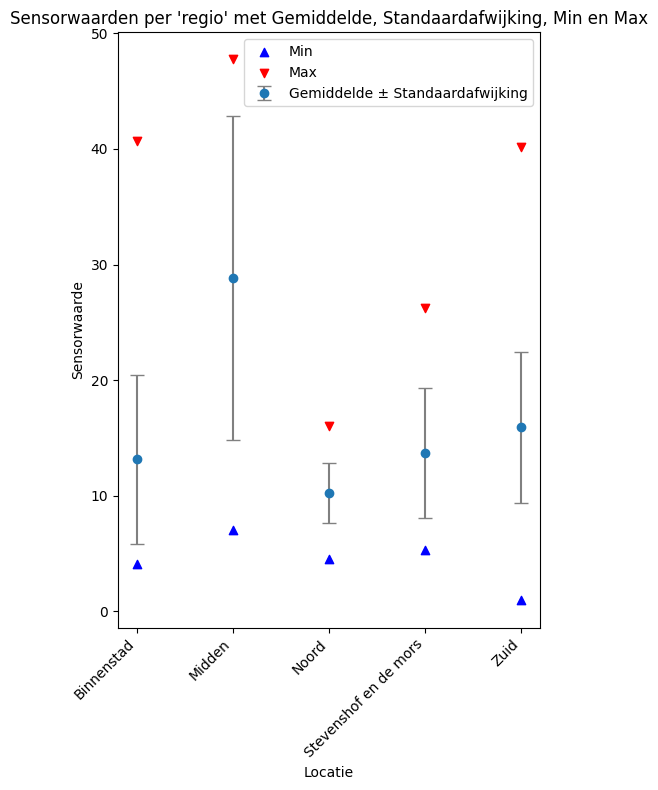

In [42]:
# Bereken statistieken (mean, std, min, max) voor de sensorwaarde 's' per locatie
location_stats = filtered_df.groupby('locatie_regio')['s'].agg(['mean', 'std', 'min', 'max']).reset_index()

# Maak de plot
plt.figure(figsize=(5, 8))
plt.errorbar(location_stats['locatie_regio'], 
             location_stats['mean'], 
             yerr=location_stats['std'], 
             fmt='o', ecolor='gray', capsize=5, label='Gemiddelde ± Standaardafwijking')

# Voeg min en max toe als extra markers
plt.scatter(location_stats['locatie_regio'], location_stats['min'], color='blue', marker='^', label='Min')
plt.scatter(location_stats['locatie_regio'], location_stats['max'], color='red', marker='v', label='Max')

# Stijl en labels toevoegen voor duidelijkheid
plt.xticks(rotation=45, ha='right')  # Rotatie aangepast naar 45 graden en uitlijning naar rechts
plt.title("Sensorwaarden per \'regio\' met Gemiddelde, Standaardafwijking, Min en Max")
plt.xlabel("Locatie")
plt.ylabel("Sensorwaarde")
plt.legend()
plt.tight_layout()

# Toon de plot
plt.show()

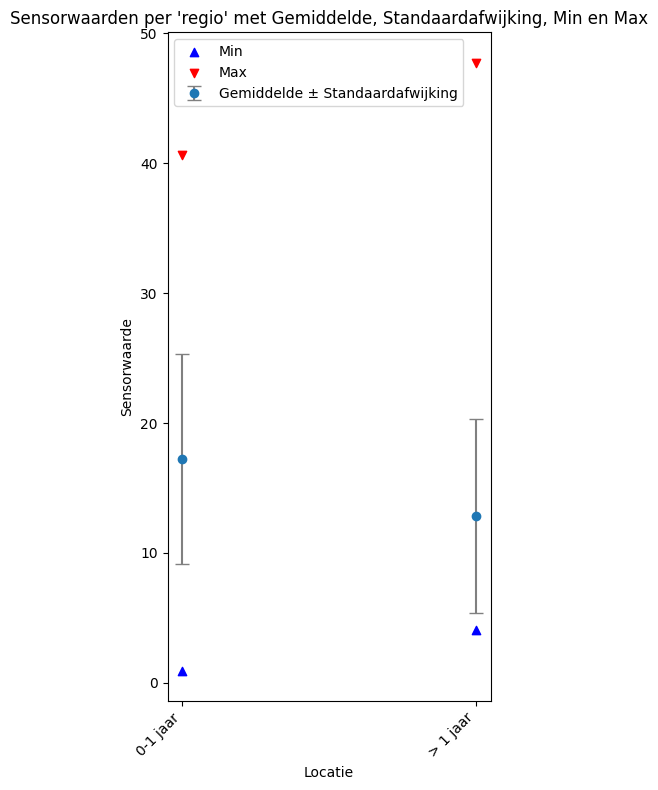

In [43]:
# Bereken statistieken (mean, std, min, max) voor de sensorwaarde 's' per locatie
location_stats = filtered_df.groupby('leeftijd_plant')['s'].agg(['mean', 'std', 'min', 'max']).reset_index()

# Maak de plot
plt.figure(figsize=(4, 8))
plt.errorbar(location_stats['leeftijd_plant'], 
             location_stats['mean'], 
             yerr=location_stats['std'], 
             fmt='o', ecolor='gray', capsize=5, label='Gemiddelde ± Standaardafwijking')

# Voeg min en max toe als extra markers
plt.scatter(location_stats['leeftijd_plant'], location_stats['min'], color='blue', marker='^', label='Min')
plt.scatter(location_stats['leeftijd_plant'], location_stats['max'], color='red', marker='v', label='Max')

# Stijl en labels toevoegen voor duidelijkheid
plt.xticks(rotation=45, ha='right')  # Rotatie aangepast naar 45 graden en uitlijning naar rechts
plt.title("Sensorwaarden per \'regio\' met Gemiddelde, Standaardafwijking, Min en Max")
plt.xlabel("Locatie")
plt.ylabel("Sensorwaarde")
plt.legend()
plt.tight_layout()

# Toon de plot
plt.show()

In [44]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Zorg ervoor dat 'datum' een datetime-formaat heeft
df['datum'] = pd.to_datetime(df['datum'])

# Maak een lijst met unieke locaties
locaties = df['locatie'].unique()

# Loop door elke locatie en plot de grafiek
for locatie in locaties:
    # Filter de data voor de huidige locatie
    data_locatie = df[df['locatie'] == locatie]

    # Sorteer data op datum voor een consistente tijdsreeks
    data_locatie = data_locatie.sort_values('datum')

    # Begin met het aanmaken van een subplot met twee y-assen
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # Voeg de sensorwaarde toe aan de primaire y-as
    fig.add_trace(
        go.Scatter(
            x=data_locatie['datum'], y=data_locatie['s'], name='Gemiddelde Sensorwaarde'),
        secondary_y=False,
    )

    # Voeg de neerslag toe aan de secundaire y-as
    fig.add_trace(
        go.Scatter(x=data_locatie['datum'],
                   y=data_locatie['n'], name='Neerslag (mm)'),
        secondary_y=True,
    )

    # Labels en titel toevoegen
    fig.update_xaxes(title_text="Datum")
    fig.update_yaxes(title_text="Gemiddelde Sensorwaarde", secondary_y=False)
    fig.update_yaxes(title_text="Neerslag (mm)", secondary_y=True)

    fig.update_layout(
        title_text=f"Sensorwaarde en Neerslag over Tijd voor {locatie}",
        template="plotly_white",
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.2,  # Plaatst de legenda onder de grafiek
            xanchor="center",
            x=0.5
        )
    )

    # Toon de grafiek
    fig.show()

    # fig.write_image(f"../final_documentatie/figuren/{locatie}.png")

In [45]:
# vergelijk bachstraat (1) met (2)
# Zorg ervoor dat 'datum' een datetime-formaat heeft
df['datum'] = pd.to_datetime(df['datum'])

# Specificeer de locaties om te visualiseren
locaties = ['Bachstraat (1)_15', 'Bachstraat (2)_15']

# Begin met het aanmaken van een lege figuur
fig = make_subplots(specs=[[{"secondary_y": False}]])

# Loop door elke geselecteerde locatie en voeg de sensorwaarde toe aan de figuur
for locatie in locaties:
    # Filter de data voor de huidige locatie
    data_locatie = df[df['locatie'] == locatie]

    # Sorteer data op datum voor een consistente tijdsreeks
    data_locatie = data_locatie.sort_values('datum')

    # Voeg de sensorwaarde toe aan de primaire y-as
    fig.add_trace(
        go.Scatter(
            x=data_locatie['datum'], 
            y=data_locatie['s'], 
            mode='lines',
            name=f'Gemiddelde Sensorwaarde - {locatie}'
        )
    )

# Labels en titel toevoegen
fig.update_xaxes(title_text="Datum")
fig.update_yaxes(title_text="Gemiddelde Sensorwaarde")

fig.update_layout(
    title_text="Sensorwaarde over Tijd voor Bachstraat (1)_15 en Bachstraat (2)_15",
    template="plotly_white",
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.2,  # Plaatst de legenda onder de grafiek
        xanchor="center",
        x=0.5
    )
)

# Toon de grafiek
fig.show()

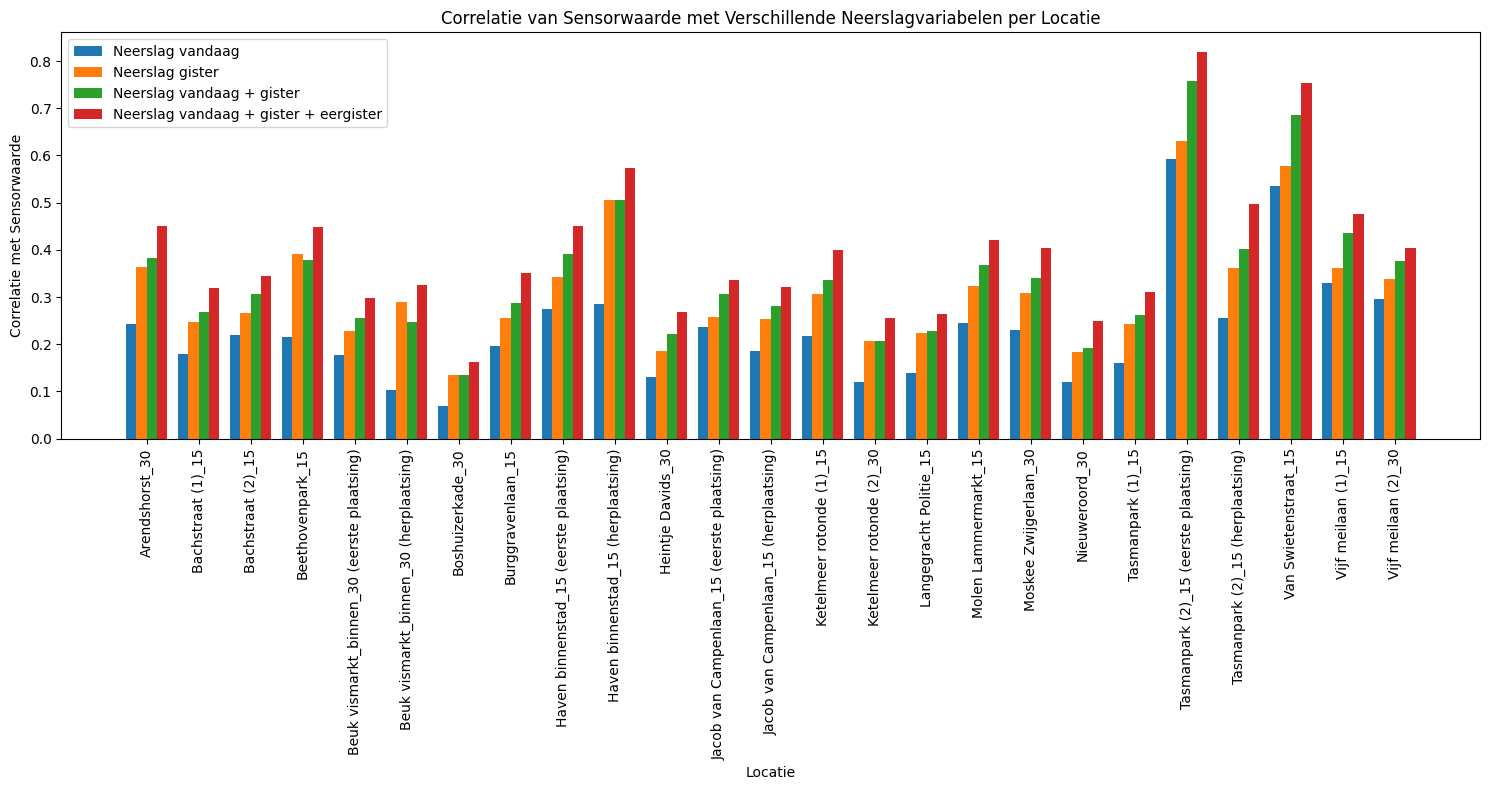

In [46]:
# filter out 'Bosplantsoen' because this is an outlier
df_filtered = df[df['soort_plant'] != 'Bosplantsoen']

# Calculate correlations for sensor value 's' with different rainfall variables per location
correlation_per_location_filtered = df_filtered.groupby('locatie').apply(lambda x: x['s'].corr(x['n'])).rename("sensor_neerslag_correlation")
correlation_n_prev_filtered = df_filtered.groupby('locatie').apply(lambda x: x['s'].corr(x['n_prev'])).rename("sensor_n_prev_correlation")
correlation_n_cum_filtered = df_filtered.groupby('locatie').apply(lambda x: x['s'].corr(x['n_cum'])).rename("sensor_n_cum_correlation")
correlation_n_cum_2_filtered = df_filtered.groupby('locatie').apply(lambda x: x['s'].corr(x['n_cum_2'])).rename("sensor_n_cum_2_correlation")

# Combine all filtered correlations into a single DataFrame for easy comparison
correlations_combined = pd.concat(
    [correlation_per_location_filtered, correlation_n_prev_filtered, 
     correlation_n_cum_filtered, correlation_n_cum_2_filtered], axis=1
).reset_index()

# Visualiseer de correlaties per locatie als staafdiagram
fig, ax = plt.subplots(figsize=(15, 8))

# Definieer de breedte van elke staaf en de posities
staaf_breedte = 0.2
locaties = np.arange(len(correlations_combined['locatie']))

# Plot elke correlatie als staven
ax.bar(locaties - 1.5 * staaf_breedte, correlations_combined['sensor_neerslag_correlation'], width=staaf_breedte, label="Neerslag vandaag")
ax.bar(locaties - 0.5 * staaf_breedte, correlations_combined['sensor_n_prev_correlation'], width=staaf_breedte, label="Neerslag gister")
ax.bar(locaties + 0.5 * staaf_breedte, correlations_combined['sensor_n_cum_correlation'], width=staaf_breedte, label="Neerslag vandaag + gister")
ax.bar(locaties + 1.5 * staaf_breedte, correlations_combined['sensor_n_cum_2_correlation'], width=staaf_breedte, label="Neerslag vandaag + gister + eergister")

# Voeg labels en titel toe
plt.xticks(locaties, correlations_combined['locatie'], rotation=90)
plt.xlabel("Locatie")
plt.ylabel("Correlatie met Sensorwaarde")
plt.title("Correlatie van Sensorwaarde met Verschillende Neerslagvariabelen per Locatie")
plt.legend()
plt.tight_layout()

# Toon de plot
plt.show()

In [47]:
# n_cum vs s_prev_diff

# Define a function to categorize 'n_cum' into bins for analysis
def categorize_rainfall(n_cum_value):
    if n_cum_value < 1:
        return '0-1 mm'
    elif 1 <= n_cum_value < 5:
        return '1-5 mm'
    elif 5 <= n_cum_value < 10:
        return '5-10 mm'
    elif 10 <= n_cum_value < 20:
        return '10-20 mm'
    elif 20 <= n_cum_value < 30:
        return '20-30 mm'
    else:
        return '>30 mm'

# Remove the specific location from the DataFrame, because this is an outlier to the dataset
df_filtered = df[df['locatie'] != 'Jacob van Campenlaan_15 (eerste plaatsing)']

# Apply categorization to 'n_cum' column
df_filtered['n_cum_category'] = df_filtered['n_cum'].apply(categorize_rainfall)

# Calculate the mean 's_prev_diff_2' by location and 'n_cum' category
mean_s_prev_diff_2_by_rain_category = df_filtered.groupby(['locatie', 'n_cum_category'])['s_prev_diff'].mean().unstack()


# Ensure correct ordering of 'n_cum_category'
correct_order = ['0-1 mm', '1-5 mm', '5-10 mm', '10-20 mm', '20-30 mm', '>30 mm']
mean_s_prev_diff_2_by_rain_category = mean_s_prev_diff_2_by_rain_category[correct_order]

# Create an interactive line plot
fig = go.Figure()

# Add a trace for each location
for locatie in mean_s_prev_diff_2_by_rain_category.index:
    fig.add_trace(go.Scatter(
        x=mean_s_prev_diff_2_by_rain_category.columns,
        y=mean_s_prev_diff_2_by_rain_category.loc[locatie],
        mode='lines+markers',
        name=locatie,
        hoverinfo='text',
        text=[f"Locatie: {locatie}<br>Neerslag Categorie: {category}<br>Gemiddelde Verandering: {value:.2f}"
              for category, value in zip(mean_s_prev_diff_2_by_rain_category.columns, 
                                         mean_s_prev_diff_2_by_rain_category.loc[locatie])]
    ))

# Customize layout with increased height
fig.update_layout(
    title="Gemiddelde Verandering in Sensorwaarde per Neerslagcategorie voor Elke Locatie",
    xaxis_title="Cumulatieve Neerslag Categorie (neerslag vandaag + gister)",
    yaxis_title="Gem.Verandering in Sensorwaarde (vandaag - gister)",
    xaxis=dict(tickmode='array', tickvals=correct_order),
    legend_title="Locatie",
    hovermode='closest',
    height=650  # Doubling the height for a taller plot
)

# Display the interactive plot
fig.show()

C:\Users\JSpan\AppData\Local\Temp\ipykernel_26964\981215132.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [48]:
# n vs s_prev_diff

# Define a function to categorize 'n_cum' into bins for analysis
def categorize_rainfall(n_cum_value):
    if n_cum_value < 1:
        return '0-1 mm'
    elif 1 <= n_cum_value < 5:
        return '1-5 mm'
    elif 5 <= n_cum_value < 10:
        return '5-10 mm'
    elif 10 <= n_cum_value < 20:
        return '10-20 mm'
    elif 20 <= n_cum_value < 30:
        return '20-30 mm'
    else:
        return '>30 mm'

# Remove the specific location from the DataFrame, because this is an outlier to the dataset
df_filtered = df[df['locatie'] != 'Jacob van Campenlaan_15 (eerste plaatsing)']

# Apply categorization to 'n_cum' column
df_filtered['n_cum_category'] = df_filtered['n'].apply(categorize_rainfall)

# Calculate the mean 's_prev_diff_2' by location and 'n_cum' category
mean_s_prev_diff_2_by_rain_category = df_filtered.groupby(['locatie', 'n_cum_category'])['s_prev_diff'].mean().unstack()

# Ensure correct ordering of 'n_cum_category'
correct_order = ['0-1 mm', '1-5 mm', '5-10 mm', '10-20 mm', '20-30 mm', '>30 mm']
mean_s_prev_diff_2_by_rain_category = mean_s_prev_diff_2_by_rain_category[correct_order]

# Create an interactive line plot
fig = go.Figure()

# Add a trace for each location
for locatie in mean_s_prev_diff_2_by_rain_category.index:
    fig.add_trace(go.Scatter(
        x=mean_s_prev_diff_2_by_rain_category.columns,
        y=mean_s_prev_diff_2_by_rain_category.loc[locatie],
        mode='lines+markers',
        name=locatie,
        hoverinfo='text',
        text=[f"Locatie: {locatie}<br>Neerslag Categorie: {category}<br>Gemiddelde Verandering: {value:.2f}"
              for category, value in zip(mean_s_prev_diff_2_by_rain_category.columns, 
                                         mean_s_prev_diff_2_by_rain_category.loc[locatie])]
    ))

# Customize layout with increased height
fig.update_layout(
    title="Gemiddelde Verandering in Sensorwaarde per Neerslagcategorie voor Elke Locatie",
    xaxis_title="Neerslag vandaag",
    yaxis_title="Gem.Verandering in Sensorwaarde (vandaag - gister)",
    xaxis=dict(tickmode='array', tickvals=correct_order),
    legend_title="Locatie",
    hovermode='closest',
    height=650  # Doubling the height for a taller plot
)

# Display the interactive plot
fig.show()

C:\Users\JSpan\AppData\Local\Temp\ipykernel_26964\2117802055.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [49]:
# n vs s_prev_diff

# Define a function to categorize 'n_cum' into bins for analysis
def categorize_rainfall(n_cum_value):
    if n_cum_value < 1:
        return '0-1 mm'
    elif 1 <= n_cum_value < 5:
        return '1-5 mm'
    elif 5 <= n_cum_value < 10:
        return '5-10 mm'
    elif 10 <= n_cum_value < 20:
        return '10-20 mm'
    elif 20 <= n_cum_value < 30:
        return '20-30 mm'
    else:
        return '>30 mm'

# Apply categorization to 'n_cum' column
df['n_cum_category'] = df['n'].apply(categorize_rainfall)

# Calculate the mean 's_prev_diff_2' by location and 'n_cum' category
mean_s_prev_diff_2_by_rain_category = df.groupby(['diepte_plaatsing', 'n_cum_category'])['s_prev_diff'].mean().unstack()

# Ensure correct ordering of 'n_cum_category'
correct_order = ['0-1 mm', '1-5 mm', '5-10 mm', '10-20 mm', '20-30 mm', '>30 mm']
mean_s_prev_diff_2_by_rain_category = mean_s_prev_diff_2_by_rain_category[correct_order]

# Create an interactive line plot
fig = go.Figure()

# Add a trace for each location
for diepte_plaatsing in mean_s_prev_diff_2_by_rain_category.index:
    fig.add_trace(go.Scatter(
        x=mean_s_prev_diff_2_by_rain_category.columns,
        y=mean_s_prev_diff_2_by_rain_category.loc[diepte_plaatsing],
        mode='lines+markers',
        name=diepte_plaatsing,
        hoverinfo='text',
        text=[f"diepte_plaatsing: {diepte_plaatsing}<br>Neerslag Categorie: {category}<br>Gemiddelde Verandering: {value:.2f}"
              for category, value in zip(mean_s_prev_diff_2_by_rain_category.columns, 
                                         mean_s_prev_diff_2_by_rain_category.loc[diepte_plaatsing])]
    ))

# Customize layout with increased height
fig.update_layout(
    title="Gemiddelde Verandering in Sensorwaarde per Neerslagcategorie voor Elke diepte_plaatsing",
    xaxis_title="Neerslag vandaag",
    yaxis_title="Gem.Verandering in Sensorwaarde (vandaag - gister)",
    xaxis=dict(tickmode='array', tickvals=correct_order),
    legend_title="diepte_plaatsing",
    hovermode='closest',
    height=650  # Doubling the height for a taller plot
)

# Display the interactive plot
fig.show()

# n_cum vs s_prev_diff

# Define a function to categorize 'n_cum' into bins for analysis
def categorize_rainfall(n_cum_value):
    if n_cum_value < 1:
        return '0-1 mm'
    elif 1 <= n_cum_value < 5:
        return '1-5 mm'
    elif 5 <= n_cum_value < 10:
        return '5-10 mm'
    elif 10 <= n_cum_value < 20:
        return '10-20 mm'
    elif 20 <= n_cum_value < 30:
        return '20-30 mm'
    else:
        return '>30 mm'

# Apply categorization to 'n_cum' column
df['n_cum_category'] = df['n_cum'].apply(categorize_rainfall)

# Calculate the mean 's_prev_diff_2' by location and 'n_cum' category
mean_s_prev_diff_2_by_rain_category = df.groupby(['diepte_plaatsing', 'n_cum_category'])['s_prev_diff'].mean().unstack()

# Ensure correct ordering of 'n_cum_category'
correct_order = ['0-1 mm', '1-5 mm', '5-10 mm', '10-20 mm', '20-30 mm', '>30 mm']
mean_s_prev_diff_2_by_rain_category = mean_s_prev_diff_2_by_rain_category[correct_order]

# Create an interactive line plot
fig = go.Figure()

# Add a trace for each location
for diepte_plaatsing in mean_s_prev_diff_2_by_rain_category.index:
    fig.add_trace(go.Scatter(
        x=mean_s_prev_diff_2_by_rain_category.columns,
        y=mean_s_prev_diff_2_by_rain_category.loc[diepte_plaatsing],
        mode='lines+markers',
        name=diepte_plaatsing,
        hoverinfo='text',
        text=[f"diepte_plaatsing: {diepte_plaatsing}<br>Neerslag Categorie: {category}<br>Gemiddelde Verandering: {value:.2f}"
              for category, value in zip(mean_s_prev_diff_2_by_rain_category.columns, 
                                         mean_s_prev_diff_2_by_rain_category.loc[diepte_plaatsing])]
    ))

# Customize layout with increased height
fig.update_layout(
    title="Gemiddelde Verandering in Sensorwaarde per Neerslagcategorie voor Elke diepte_plaatsing",
    xaxis_title="Cumulatieve Neerslag Categorie (neerslag vandaag + gister)",
    yaxis_title="Gem.Verandering in Sensorwaarde (vandaag - gister)",
    xaxis=dict(tickmode='array', tickvals=correct_order),
    legend_title="diepte_plaatsing",
    hovermode='closest',
    height=650  # Doubling the height for a taller plot
)

# Display the interactive plot
fig.show()

In [50]:
# n vs s_prev_diff
df_filtered = df[df['soort_plant'] != 'Bosplantsoen']

# Define a function to categorize 'n_cum' into bins for analysis
def categorize_rainfall(n_cum_value):
    if n_cum_value < 1:
        return '0-1 mm'
    elif 1 <= n_cum_value < 5:
        return '1-5 mm'
    elif 5 <= n_cum_value < 10:
        return '5-10 mm'
    elif 10 <= n_cum_value < 20:
        return '10-20 mm'
    elif 20 <= n_cum_value < 30:
        return '20-30 mm'
    else:
        return '>30 mm'

# Apply categorization to 'n_cum' column
df_filtered['n_cum_category'] = df_filtered['n'].apply(categorize_rainfall)

# Calculate the mean 's_prev_diff_2' by location and 'n_cum' category
mean_s_prev_diff_2_by_rain_category = df_filtered.groupby(['soort_plant', 'n_cum_category'])['s_prev_diff'].mean().unstack()

# Ensure correct ordering of 'n_cum_category'
correct_order = ['0-1 mm', '1-5 mm', '5-10 mm', '10-20 mm', '20-30 mm', '>30 mm']
mean_s_prev_diff_2_by_rain_category = mean_s_prev_diff_2_by_rain_category[correct_order]

# Create an interactive line plot
fig = go.Figure()

# Add a trace for each location
for soort_plant in mean_s_prev_diff_2_by_rain_category.index:
    fig.add_trace(go.Scatter(
        x=mean_s_prev_diff_2_by_rain_category.columns,
        y=mean_s_prev_diff_2_by_rain_category.loc[soort_plant],
        mode='lines+markers',
        name=soort_plant,
        hoverinfo='text',
        text=[f"soort_plant: {soort_plant}<br>Neerslag Categorie: {category}<br>Gemiddelde Verandering: {value:.2f}"
              for category, value in zip(mean_s_prev_diff_2_by_rain_category.columns, 
                                         mean_s_prev_diff_2_by_rain_category.loc[soort_plant])]
    ))

# Customize layout with increased height
fig.update_layout(
    title="Gemiddelde Verandering in Sensorwaarde per Neerslagcategorie voor Elke soort_plant",
    xaxis_title="Neerslag vandaag",
    yaxis_title="Gem.Verandering in Sensorwaarde (vandaag - gister)",
    xaxis=dict(tickmode='array', tickvals=correct_order),
    legend_title="soort_plant",
    hovermode='closest',
    height=650  # Doubling the height for a taller plot
)

# Display the interactive plot
fig.show()

# n_cum vs s_prev_diff

# Define a function to categorize 'n_cum' into bins for analysis
def categorize_rainfall(n_cum_value):
    if n_cum_value < 1:
        return '0-1 mm'
    elif 1 <= n_cum_value < 5:
        return '1-5 mm'
    elif 5 <= n_cum_value < 10:
        return '5-10 mm'
    elif 10 <= n_cum_value < 20:
        return '10-20 mm'
    elif 20 <= n_cum_value < 30:
        return '20-30 mm'
    else:
        return '>30 mm'

# Apply categorization to 'n_cum' column
df_filtered['n_cum_category'] = df_filtered['n_cum'].apply(categorize_rainfall)

# Calculate the mean 's_prev_diff_2' by location and 'n_cum' category
mean_s_prev_diff_2_by_rain_category = df_filtered.groupby(['soort_plant', 'n_cum_category'])['s_prev_diff'].mean().unstack()

# Ensure correct ordering of 'n_cum_category'
correct_order = ['0-1 mm', '1-5 mm', '5-10 mm', '10-20 mm', '20-30 mm', '>30 mm']
mean_s_prev_diff_2_by_rain_category = mean_s_prev_diff_2_by_rain_category[correct_order]

# Create an interactive line plot
fig = go.Figure()

# Add a trace for each location
for soort_plant in mean_s_prev_diff_2_by_rain_category.index:
    fig.add_trace(go.Scatter(
        x=mean_s_prev_diff_2_by_rain_category.columns,
        y=mean_s_prev_diff_2_by_rain_category.loc[soort_plant],
        mode='lines+markers',
        name=soort_plant,
        hoverinfo='text',
        text=[f"soort_plant: {soort_plant}<br>Neerslag Categorie: {category}<br>Gemiddelde Verandering: {value:.2f}"
              for category, value in zip(mean_s_prev_diff_2_by_rain_category.columns, 
                                         mean_s_prev_diff_2_by_rain_category.loc[soort_plant])]
    ))

# Customize layout with increased height
fig.update_layout(
    title="Gemiddelde Verandering in Sensorwaarde per Neerslagcategorie voor Elke soort_plant",
    xaxis_title="Cumulatieve Neerslag Categorie (neerslag vandaag + gister)",
    yaxis_title="Gem.Verandering in Sensorwaarde (vandaag - gister)",
    xaxis=dict(tickmode='array', tickvals=correct_order),
    legend_title="soort_plant",
    hovermode='closest',
    height=650  # Doubling the height for a taller plot
)

# Display the interactive plot
fig.show()

C:\Users\JSpan\AppData\Local\Temp\ipykernel_26964\3769618781.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



C:\Users\JSpan\AppData\Local\Temp\ipykernel_26964\3769618781.py:77: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [51]:
# n vs s_prev_diff

# Define a function to categorize 'n_cum' into bins for analysis
def categorize_rainfall(n_cum_value):
    if n_cum_value < 1:
        return '0-1 mm'
    elif 1 <= n_cum_value < 5:
        return '1-5 mm'
    elif 5 <= n_cum_value < 10:
        return '5-10 mm'
    elif 10 <= n_cum_value < 20:
        return '10-20 mm'
    elif 20 <= n_cum_value < 30:
        return '20-30 mm'
    else:
        return '>30 mm'

# Apply categorization to 'n_cum' column
df['n_cum_category'] = df['n'].apply(categorize_rainfall)

# Calculate the mean 's_prev_diff_2' by location and 'n_cum' category
mean_s_prev_diff_2_by_rain_category = df.groupby(['locatie_regio', 'n_cum_category'])['s_prev_diff'].mean().unstack()

# Ensure correct ordering of 'n_cum_category'
correct_order = ['0-1 mm', '1-5 mm', '5-10 mm', '10-20 mm', '20-30 mm', '>30 mm']
mean_s_prev_diff_2_by_rain_category = mean_s_prev_diff_2_by_rain_category[correct_order]

# Create an interactive line plot
fig = go.Figure()

# Add a trace for each location
for locatie_regio in mean_s_prev_diff_2_by_rain_category.index:
    fig.add_trace(go.Scatter(
        x=mean_s_prev_diff_2_by_rain_category.columns,
        y=mean_s_prev_diff_2_by_rain_category.loc[locatie_regio],
        mode='lines+markers',
        name=locatie_regio,
        hoverinfo='text',
        text=[f"locatie_regio: {locatie_regio}<br>Neerslag Categorie: {category}<br>Gemiddelde Verandering: {value:.2f}"
              for category, value in zip(mean_s_prev_diff_2_by_rain_category.columns, 
                                         mean_s_prev_diff_2_by_rain_category.loc[locatie_regio])]
    ))

# Customize layout with increased height
fig.update_layout(
    title="Gemiddelde Verandering in Sensorwaarde per Neerslagcategorie voor Elke locatie_regio",
    xaxis_title="Neerslag vandaag",
    yaxis_title="Gem.Verandering in Sensorwaarde (vandaag - gister)",
    xaxis=dict(tickmode='array', tickvals=correct_order),
    legend_title="locatie_regio",
    hovermode='closest',
    height=650  # Doubling the height for a taller plot
)

# Display the interactive plot
fig.show()

# n_cum vs s_prev_diff

# Define a function to categorize 'n_cum' into bins for analysis
def categorize_rainfall(n_cum_value):
    if n_cum_value < 1:
        return '0-1 mm'
    elif 1 <= n_cum_value < 5:
        return '1-5 mm'
    elif 5 <= n_cum_value < 10:
        return '5-10 mm'
    elif 10 <= n_cum_value < 20:
        return '10-20 mm'
    elif 20 <= n_cum_value < 30:
        return '20-30 mm'
    else:
        return '>30 mm'

# Apply categorization to 'n_cum' column
df['n_cum_category'] = df['n_cum'].apply(categorize_rainfall)

# Calculate the mean 's_prev_diff_2' by location and 'n_cum' category
mean_s_prev_diff_2_by_rain_category = df.groupby(['locatie_regio', 'n_cum_category'])['s_prev_diff'].mean().unstack()

# Ensure correct ordering of 'n_cum_category'
correct_order = ['0-1 mm', '1-5 mm', '5-10 mm', '10-20 mm', '20-30 mm', '>30 mm']
mean_s_prev_diff_2_by_rain_category = mean_s_prev_diff_2_by_rain_category[correct_order]

# Create an interactive line plot
fig = go.Figure()

# Add a trace for each location
for locatie_regio in mean_s_prev_diff_2_by_rain_category.index:
    fig.add_trace(go.Scatter(
        x=mean_s_prev_diff_2_by_rain_category.columns,
        y=mean_s_prev_diff_2_by_rain_category.loc[locatie_regio],
        mode='lines+markers',
        name=locatie_regio,
        hoverinfo='text',
        text=[f"locatie_regio: {locatie_regio}<br>Neerslag Categorie: {category}<br>Gemiddelde Verandering: {value:.2f}"
              for category, value in zip(mean_s_prev_diff_2_by_rain_category.columns, 
                                         mean_s_prev_diff_2_by_rain_category.loc[locatie_regio])]
    ))

# Customize layout with increased height
fig.update_layout(
    title="Gemiddelde Verandering in Sensorwaarde per Neerslagcategorie voor Elke locatie_regio",
    xaxis_title="Cumulatieve Neerslag Categorie (neerslag vandaag + gister)",
    yaxis_title="Gem.Verandering in Sensorwaarde (vandaag - gister)",
    xaxis=dict(tickmode='array', tickvals=correct_order),
    legend_title="locatie_regio",
    hovermode='closest',
    height=650  # Doubling the height for a taller plot
)

# Display the interactive plot
fig.show()

In [52]:
# n vs s_prev_diff

# Define a function to categorize 'n_cum' into bins for analysis
def categorize_rainfall(n_cum_value):
    if n_cum_value < 1:
        return '0-1 mm'
    elif 1 <= n_cum_value < 5:
        return '1-5 mm'
    elif 5 <= n_cum_value < 10:
        return '5-10 mm'
    elif 10 <= n_cum_value < 20:
        return '10-20 mm'
    elif 20 <= n_cum_value < 30:
        return '20-30 mm'
    else:
        return '>30 mm'

# Apply categorization to 'n_cum' column
df['n_cum_category'] = df['n'].apply(categorize_rainfall)

# Calculate the mean 's_prev_diff_2' by location and 'n_cum' category
mean_s_prev_diff_2_by_rain_category = df.groupby(['leeftijd_plant', 'n_cum_category'])['s_prev_diff'].mean().unstack()

# Ensure correct ordering of 'n_cum_category'
correct_order = ['0-1 mm', '1-5 mm', '5-10 mm', '10-20 mm', '20-30 mm', '>30 mm']
mean_s_prev_diff_2_by_rain_category = mean_s_prev_diff_2_by_rain_category[correct_order]

# Create an interactive line plot
fig = go.Figure()

# Add a trace for each location
for leeftijd_plant in mean_s_prev_diff_2_by_rain_category.index:
    fig.add_trace(go.Scatter(
        x=mean_s_prev_diff_2_by_rain_category.columns,
        y=mean_s_prev_diff_2_by_rain_category.loc[leeftijd_plant],
        mode='lines+markers',
        name=leeftijd_plant,
        hoverinfo='text',
        text=[f"leeftijd_plant: {leeftijd_plant}<br>Neerslag Categorie: {category}<br>Gemiddelde Verandering: {value:.2f}"
              for category, value in zip(mean_s_prev_diff_2_by_rain_category.columns, 
                                         mean_s_prev_diff_2_by_rain_category.loc[leeftijd_plant])]
    ))

# Customize layout with increased height
fig.update_layout(
    title="Gemiddelde Verandering in Sensorwaarde per Neerslagcategorie voor Elke leeftijd_plant",
    xaxis_title="Neerslag vandaag",
    yaxis_title="Gem.Verandering in Sensorwaarde (vandaag - gister)",
    xaxis=dict(tickmode='array', tickvals=correct_order),
    legend_title="leeftijd_plant",
    hovermode='closest',
    height=650  # Doubling the height for a taller plot
)

# Display the interactive plot
fig.show()

# n_cum vs s_prev_diff

# Define a function to categorize 'n_cum' into bins for analysis
def categorize_rainfall(n_cum_value):
    if n_cum_value < 1:
        return '0-1 mm'
    elif 1 <= n_cum_value < 5:
        return '1-5 mm'
    elif 5 <= n_cum_value < 10:
        return '5-10 mm'
    elif 10 <= n_cum_value < 20:
        return '10-20 mm'
    elif 20 <= n_cum_value < 30:
        return '20-30 mm'
    else:
        return '>30 mm'

# Apply categorization to 'n_cum' column
df['n_cum_category'] = df['n_cum'].apply(categorize_rainfall)

# Calculate the mean 's_prev_diff_2' by location and 'n_cum' category
mean_s_prev_diff_2_by_rain_category = df.groupby(['leeftijd_plant', 'n_cum_category'])['s_prev_diff'].mean().unstack()

# Ensure correct ordering of 'n_cum_category'
correct_order = ['0-1 mm', '1-5 mm', '5-10 mm', '10-20 mm', '20-30 mm', '>30 mm']
mean_s_prev_diff_2_by_rain_category = mean_s_prev_diff_2_by_rain_category[correct_order]

# Create an interactive line plot
fig = go.Figure()

# Add a trace for each location
for leeftijd_plant in mean_s_prev_diff_2_by_rain_category.index:
    fig.add_trace(go.Scatter(
        x=mean_s_prev_diff_2_by_rain_category.columns,
        y=mean_s_prev_diff_2_by_rain_category.loc[leeftijd_plant],
        mode='lines+markers',
        name=leeftijd_plant,
        hoverinfo='text',
        text=[f"leeftijd_plant: {leeftijd_plant}<br>Neerslag Categorie: {category}<br>Gemiddelde Verandering: {value:.2f}"
              for category, value in zip(mean_s_prev_diff_2_by_rain_category.columns, 
                                         mean_s_prev_diff_2_by_rain_category.loc[leeftijd_plant])]
    ))

# Customize layout with increased height
fig.update_layout(
    title="Gemiddelde Verandering in Sensorwaarde per Neerslagcategorie voor Elke leeftijd_plant",
    xaxis_title="Cumulatieve Neerslag Categorie (neerslag vandaag + gister)",
    yaxis_title="Gem.Verandering in Sensorwaarde (vandaag - gister)",
    xaxis=dict(tickmode='array', tickvals=correct_order),
    legend_title="leeftijd_plant",
    hovermode='closest',
    height=650  # Doubling the height for a taller plot
)

# Display the interactive plot
fig.show()

# Drempelwaarde 

In [53]:
# # Recalculate thresholds for permittivity (`gem_meetwaarde`) per location
# # using the 25th percentile instead of the minimum

# dry_soil_conditions_final = df[(df['n_cum_2'] > 20) & (df['s_prev_diff'] <= 0)]

# # Group by location and calculate the 25th percentile
# # thresholds_per_location_percentile = dry_soil_conditions_final.groupby('locatie')['gem_meetwaarde'].quantile(0.25)
# thresholds_per_location_percentile = dry_soil_conditions_final.groupby('locatie')['gem_meetwaarde'].min()

# # Convert to a DataFrame for clarity
# thresholds_per_location_percentile_df = thresholds_per_location_percentile.reset_index()
# thresholds_per_location_percentile_df.columns = ['Location', 'Threshold_Permittivity']

# thresholds_per_location_percentile_df


In [54]:
# # Recalculate thresholds for permittivity (`gem_meetwaarde`) per location
# # using 10% above the minimum permittivity

# # Group by location and calculate the minimum permittivity
# min_permittivity_per_location = dry_soil_conditions_final.groupby('locatie')['gem_meetwaarde'].min()

# # Add 10% to the minimum permittivity to define the threshold
# thresholds_per_location_final_df = min_permittivity_per_location * 1.20

# # Convert to a DataFrame for clarity
# thresholds_per_location_final_df = thresholds_per_location_final_df.reset_index()
# thresholds_per_location_final_df.columns = ['Location', 'Threshold_Permittivity']


In [55]:
# # Define a dry period as 3 consecutive days where 'n' < 1
# # Create a rolling sum of the 'n' values over a 3-day window to identify dry periods
# df['is_dry_period'] = df['n'].rolling(window=3, min_periods=3).apply(lambda x: all(x < 1), raw=True)

# # Filter for rows that are part of a dry period
# dry_period_rows = df[df['is_dry_period'] == 1]

# # Calculate the average `s_prev_diff` during dry periods, grouped by location
# avg_decrease_speed_per_location_dry_period = (
#     dry_period_rows.groupby('locatie')['s_prev_diff'].quantile(0.25)
# )

# # Recalculate thresholds using minimum permittivity + (3 * average speed of decrease during dry periods)
# thresholds_per_location_final_df = (
#     min_permittivity_per_location + (3*abs(avg_decrease_speed_per_location_dry_period))
# )

# # Convert to a DataFrame for clarity
# thresholds_per_location_final_df = thresholds_per_location_final_df.reset_index()
# thresholds_per_location_final_df.columns = ['Location', 'Threshold_Permittivity']

# thresholds_per_location_final_df

In [56]:
# Step 1: Calculate thresholds_per_location_min
dry_soil_conditions_final = df[(df['n_cum_2'] > 10) & (df['s_prev_diff'] <= 0.5)]
thresholds_per_location_min = dry_soil_conditions_final.groupby('locatie')['gem_meetwaarde'].quantile(0.05)

# Step 2: Identify dry periods (3 consecutive days where 'n' < 1)
df['is_dry_period'] = df['n'].rolling(window=3, min_periods=3).apply(lambda x: all(x < 1), raw=True)

# Step 3: Filter rows for dry periods and calculate average speed of decrease during these periods
dry_period_rows = df[df['is_dry_period'] == 1]
avg_decrease_speed_per_location_dry_period = (
    dry_period_rows.groupby('locatie')['s_prev_diff'].mean().abs()
)

# Step 4: Recalculate thresholds based on the formula
thresholds_per_location_final_df = (
    thresholds_per_location_min + (3 * avg_decrease_speed_per_location_dry_period)
).reset_index()

thresholds_per_location_final_df.columns = ['Location', 'Threshold_Permittivity']

# Step 5: Add minimum and maximum value of 's' for each location and rename column
df_new = df.copy()
df_new.rename(columns={'s': 'sensorwaarde'}, inplace=True)

min_max_values = df_new.groupby('locatie')['sensorwaarde'].agg(['min', 'max']).reset_index()
min_max_values.columns = ['Location', 'Min_Sensorwaarde', 'Max_Sensorwaarde']

# Step 6: Merge min/max values with thresholds_per_location_final_df_new
df_new = thresholds_per_location_final_df.merge(min_max_values, on='Location')

# Step 7: Calculate the percentages
df_new['Percentage_van_min'] = (
    (df_new['Threshold_Permittivity'] - df_new['Min_Sensorwaarde']) /
    df_new['Min_Sensorwaarde'] * 100
)

df_new['Percentage_van_max'] = (
    df_new['Threshold_Permittivity'] /
    df_new['Max_Sensorwaarde'] * 100
)

# Rounding columns as specified
df_new['Threshold_Permittivity'] = df_new['Threshold_Permittivity'].round(2)
df_new['Min_Sensorwaarde'] = df_new['Min_Sensorwaarde'].round(2)
df_new['Max_Sensorwaarde'] = df_new['Max_Sensorwaarde'].round(2)
df_new['Percentage_van_min'] = df_new['Percentage_van_min'].round(0).astype(int).astype(str) + '%'
df_new['Percentage_van_max'] = df_new['Percentage_van_max'].round(0).astype(int).astype(str) + '%'

# Final result
display(df_new)

# Convert percentage columns to numeric for plotting
df_new["Percentage_van_min"] = df_new["Percentage_van_min"].str.rstrip('%').astype(float)
df_new["Percentage_van_max"] = df_new["Percentage_van_max"].str.rstrip('%').astype(float)


,Location,Threshold_Permittivity,Min_Sensorwaarde,Max_Sensorwaarde,Percentage_van_min,Percentage_van_max
0,Arendshorst_30,5.65,4.86,11.25,16%,50%
1,Bachstraat (1)_15,6.44,5.10,20.47,26%,31%
2,Bachstraat (2)_15,6.76,5.75,36.08,18%,19%
3,Beethovenpark_15,10.74,9.29,28.47,16%,38%
4,Beuk vismarkt_binnen_30 (eerste plaatsing),23.31,21.78,40.66,7%,57%
5,Beuk vismarkt_binnen_30 (herplaatsing),15.94,14.38,27.38,11%,58%
6,Boshuizerkade_30,5.86,5.08,16.00,15%,37%
7,Burggravenlaan_15,6.59,5.89,16.44,12%,40%
8,Haven binnenstad_15 (eerste plaatsing),10.63,7.04,18.62,51%,57%
9,Haven binnenstad_15 (herplaatsing),40.33,35.18,47.74,15%,84%


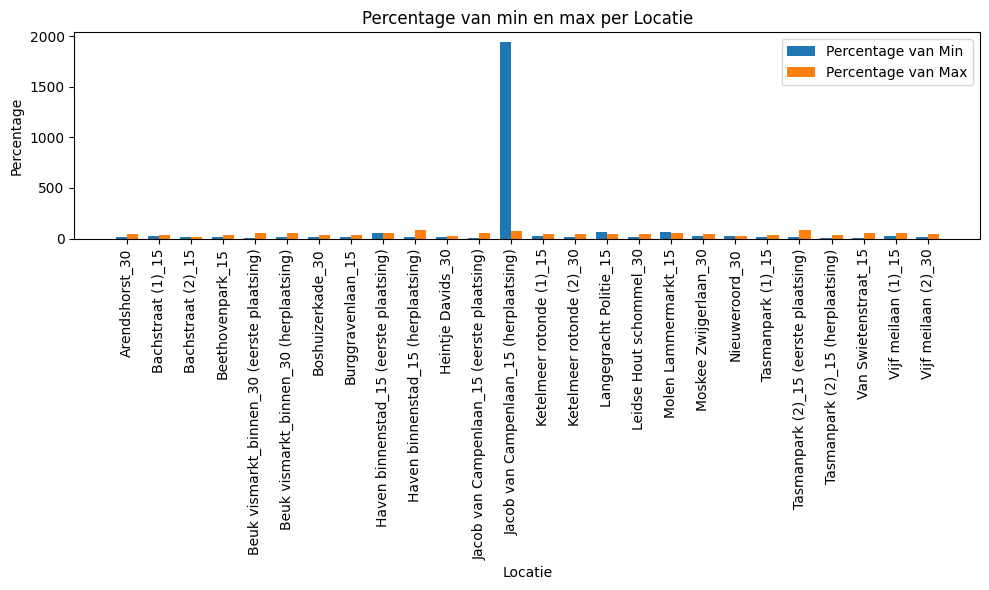

In [57]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(df_new["Location"]))
bar_width = 0.35

# Bars for Percentage_van_min
ax.bar(
    [i - bar_width / 2 for i in x], 
    df_new["Percentage_van_min"], 
    width=bar_width, 
    label="Percentage van Min"
)

# Bars for Percentage_van_max
ax.bar(
    [i + bar_width / 2 for i in x], 
    df_new["Percentage_van_max"], 
    width=bar_width, 
    label="Percentage van Max"
)

# Labels and title
ax.set_xticks(x)
# ax.set_xticklabels(df_new["Location"])
ax.set_xticklabels(df_new["Location"], rotation=90)
ax.set_ylabel("Percentage")
ax.set_xlabel("Locatie")
ax.set_title("Percentage van min en max per Locatie")
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [58]:
# Calculate Percentage_From_Min and Percentage_From_Max
df_stats = df_new.copy()

df_stats['Percentage_From_Min'] = (
    (df_stats['Threshold_Permittivity'] - df_stats['Min_Sensorwaarde']) / df_stats['Min_Sensorwaarde'] * 100
)
df_stats['Percentage_From_Max'] = (
    df_stats['Threshold_Permittivity'] / df_stats['Max_Sensorwaarde'] * 100
)

# Calculate statistics for Percentage_From_Min and Percentage_From_Max
df_stats = df_stats[['Percentage_van_min', 'Percentage_van_max']].agg(
    ['min', 'max', 'median', 'mean', 'std']
).reset_index()

# Rename columns for clarity
df_stats.rename(columns={'index': 'Metric'}, inplace=True)

df_stats

,Metric,Percentage_van_min,Percentage_van_max
0,min,5.000000,19.000000
1,max,1941.000000,89.000000
2,median,16.500000,49.000000
3,mean,95.115385,48.576923
4,std,376.810756,16.800412


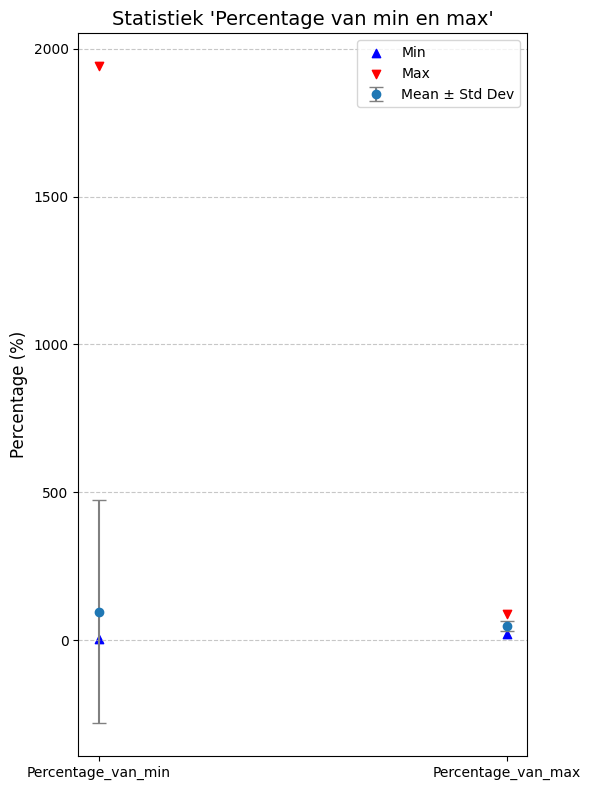

In [59]:
df_stats = df_new[['Percentage_van_min', 'Percentage_van_max']].agg(['mean', 'std', 'min', 'max']).T

df_stats.reset_index(inplace=True)
df_stats.rename(columns={'index': 'Metric'}, inplace=True)

# Create the plot
plt.figure(figsize=(6, 8))

# Error bars for mean ± std
plt.errorbar(df_stats['Metric'], 
             df_stats['mean'], 
             yerr=df_stats['std'], 
             fmt='o', ecolor='gray', capsize=5, label='Mean ± Std Dev')

# Add min and max as extra markers
plt.scatter(df_stats['Metric'], df_stats['min'], color='blue', marker='^', label='Min')
plt.scatter(df_stats['Metric'], df_stats['max'], color='red', marker='v', label='Max')

# Add styling and labels for clarity
plt.title("Statistiek 'Percentage van min en max'", fontsize=14)
# plt.xlabel("Metric", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

In [60]:
locaties

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24])

In [61]:
# Zorg ervoor dat 'datum' een datetime-formaat heeft
df['datum'] = pd.to_datetime(df['datum'])

# Maak een lijst met unieke locaties
locaties = df['locatie'].unique()

# Maak een dictionary van locatie naar threshold
thresholds_dict = thresholds_per_location_final_df.set_index('Location')['Threshold_Permittivity'].to_dict()

# Loop door elke locatie en plot de grafiek
for locatie in locaties:
    # Filter de data voor de huidige locatie
    data_locatie = df[df['locatie'] == locatie]

    # Sorteer data op datum voor een consistente tijdsreeks
    data_locatie = data_locatie.sort_values('datum')

    # Begin met het aanmaken van een subplot met twee y-assen
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # Voeg de sensorwaarde toe aan de primaire y-as
    fig.add_trace(
        go.Scatter(
            x=data_locatie['datum'], 
            y=data_locatie['gem_meetwaarde'], 
            name='Gemiddelde Sensorwaarde'
        ),
        secondary_y=False,
    )

    # Voeg de neerslag toe aan de secundaire y-as
    fig.add_trace(
        go.Scatter(
            x=data_locatie['datum'],
            y=data_locatie['n_cum'], 
            name='Neerslag (mm)'
        ),
        secondary_y=True,
    )

    # Voeg de drempelwaarde toe als een zwarte gestippelde lijn
    if locatie in thresholds_dict:
        threshold_value = thresholds_dict[locatie]
        fig.add_trace(
            go.Scatter(
                x=data_locatie['datum'], 
                y=[threshold_value] * len(data_locatie), 
                mode='lines', 
                name='Drempelwaarde', 
                line=dict(color='black', dash='dot')
            ),
            secondary_y=False,
        )

    # Labels en titel toevoegen
    fig.update_xaxes(title_text="Datum")
    fig.update_yaxes(
        title_text="Gemiddelde Sensorwaarde",
        secondary_y=False,
        range=[0, None]  # Zorg dat de Y-as van de sensorwaarde altijd vanaf 0 begint
    )
    fig.update_yaxes(title_text="Neerslag (mm)", secondary_y=True)

    # Stel expliciete afmetingen in
    fig.update_layout(
        title_text=f"Sensorwaarde en Neerslag over Tijd voor {locatie}",
        template="plotly_white",
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.2,  # Plaatst de legenda onder de grafiek
            xanchor="center",
            x=0.5
        ),
        width=1500,  # Breedte in pixels
        height=750   # Hoogte in pixels
    )

    # Toon de grafiek
    fig.show()

    # Sla de grafiek op met dezelfde afmetingen
    fig.write_image(f"../final_documentatie/figuren/{locatie}.png", width=1500, height=750)



FileNotFoundError: [Errno 2] No such file or directory: '..\\final_documentatie\\figuren\\Arendshorst_30.png'

# Elimineer buitjes voor de stof

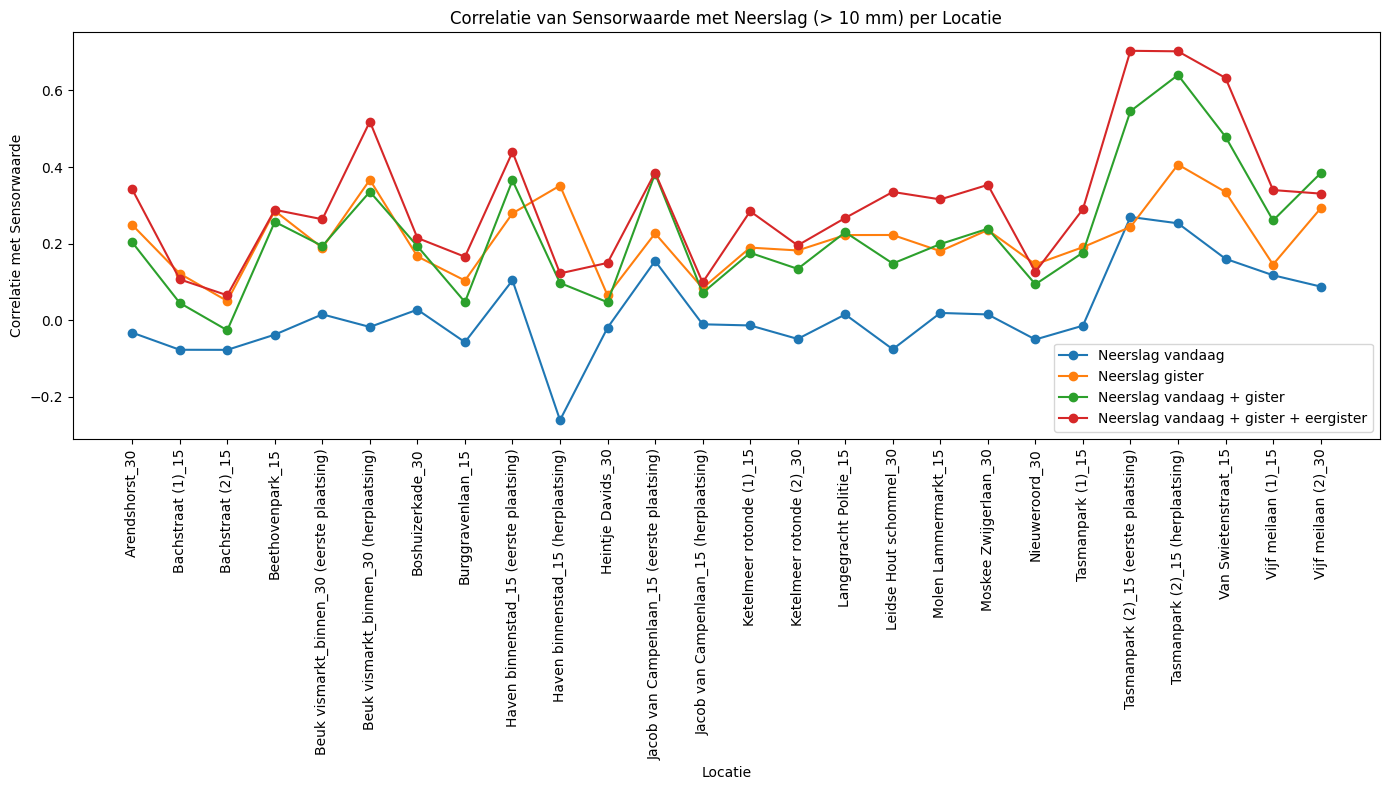

In [ ]:
# Assuming 'df' is already loaded and contains your dataset

# Ensure 'datum' column is in datetime format
df['datum'] = pd.to_datetime(df['datum'])

# Filter data for rainfall ('n_cum') > 10 mm
df_filtered = df[df['n_cum'] > 10]

# Calculate correlations for sensor value 's' with different rainfall variables per location
correlation_per_location_filtered = df_filtered.groupby('locatie').apply(lambda x: x['s'].corr(x['n'])).rename("sensor_neerslag_correlation")
correlation_n_prev_filtered = df_filtered.groupby('locatie').apply(lambda x: x['s'].corr(x['n_prev'])).rename("sensor_n_prev_correlation")
correlation_n_cum_filtered = df_filtered.groupby('locatie').apply(lambda x: x['s'].corr(x['n_cum'])).rename("sensor_n_cum_correlation")
correlation_n_cum_2_filtered = df_filtered.groupby('locatie').apply(lambda x: x['s'].corr(x['n_cum_2'])).rename("sensor_n_cum_2_correlation")

# Combine all filtered correlations into a single DataFrame for easy comparison
correlations_combined_filtered = pd.concat(
    [correlation_per_location_filtered, correlation_n_prev_filtered, 
     correlation_n_cum_filtered, correlation_n_cum_2_filtered], axis=1
).reset_index()

# Plot the correlations per location
fig, ax = plt.subplots(figsize=(14, 8))

# Plot each correlation type by location
ax.plot(correlations_combined_filtered['locatie'], correlations_combined_filtered['sensor_neerslag_correlation'], 
        label="Neerslag vandaag", marker='o')
ax.plot(correlations_combined_filtered['locatie'], correlations_combined_filtered['sensor_n_prev_correlation'], 
        label="Neerslag gister", marker='o')
ax.plot(correlations_combined_filtered['locatie'], correlations_combined_filtered['sensor_n_cum_correlation'], 
        label="Neerslag vandaag + gister", marker='o')
ax.plot(correlations_combined_filtered['locatie'], correlations_combined_filtered['sensor_n_cum_2_correlation'], 
        label="Neerslag vandaag + gister + eergister", marker='o')

# Add labels and title
plt.xticks(rotation=90)
plt.xlabel("Locatie")
plt.ylabel("Correlatie met Sensorwaarde")
plt.title("Correlatie van Sensorwaarde met Neerslag (> 10 mm) per Locatie")
plt.legend()
plt.tight_layout()

# Display the plot
plt.show()

### 1.2 Measures & Categories
De **measure_lst_org** bevat alle namen van alle measure (incl. berekende kolommen)

De **category_lst_org** bevat alle eigenschappen van de locatie waar de sensor is geplaatst. Deze gebruiken we om analyseren welke impact bepaalde eigenschappen hebben op de meetwaardes. Daalt de vochtigheid in de grond in de buurt van bomen sneller dan bij planten? Wordt er in regio noord het wat er beter vastgehouden dan in andere regio's?



In [ ]:
# de category_lst bevat alle eigenschappen van de locatie waar de sensor is geplaatst
category_lst_org = ['locatie','locatie_regio','soort_plant','extra_omschrijving','leeftijd_plant','diepte_plaatsing']

# de measure_lst bevat alle namen van de measures (incl berekende kolommen)
measure_lst_org = ['gem_meetwaarde','windsnelheid', 'zonneschijn_duur', 'neerslag_duur', 'luchtdruk',
                'bewolking', 'vochtigheid', 'verdamping', 'temperatuur', 'neerslag',
                's', 'n', 's_prev', 's_prev_diff', 's_prev_diff_2', 's_prev_diff_perc',
                's_norm', 's_min_max', 's_min_max_prev', 's_min_max_prev_2',
                's_increase', 'n_prev', 'n_prev_2', 'n_cum', 'n_cum_2']

## 2. Inspecteer Data

Inspecteer data (visually). Plot alle sensordata in één grafiek en check of er outliers of afwijkende events hebben plaatsgevonden  

In [ ]:
df_visual = df.copy()
# df_visual = df_visual[df_visual['datum'] > datetime(2023, 7, 3)].copy()
df_visual.sort_values(by=['locatie', 'datum'], inplace=True)

fig = px.line(df_visual, x='datum', y='s', color='locatie', title='Time Series van alle sensors',
              labels={'meetwaarde': 'Permittivity', 'datum': 'Time'},
              line_group='locatie', hover_name='locatie')

fig.show()

c:\Users\JSpan\AppData\Local\anaconda3\envs\waterleiden\Lib\site-packages\_plotly_utils\basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [ ]:
# outlier_detection with Z-scores en IQR scores

outlier_detection = False

if outlier_detection:
    from scipy import stats
    import numpy as np

    # Z-scores
    def detect_outliers_zscore(group):
        threshold = 3  # this is a commonly used value, but you can adjust as needed
        z_scores = stats.zscore(group['gem_meetwaarde'])
        abs_z_scores = np.abs(z_scores)
        outliers = abs_z_scores > threshold
        return group[outliers]


    df_outliers_zscore = df.groupby('locatie').apply(
        detect_outliers_zscore).reset_index(drop=True)
    df_outliers_zscoredf_outliers_zscore = df.groupby('locatie').apply(
        detect_outliers_zscore).reset_index(drop=True)

    display(df_outliers_zscore.head(5))

    # With IQR scores
    def detect_outliers_iqr(group):
        Q1 = group['gem_meetwaarde'].quantile(0.25)
        Q3 = group['gem_meetwaarde'].quantile(0.75)
        IQR = Q3 - Q1
        outliers = (group['gem_meetwaarde'] < (Q1 - 1.5 * IQR)
                    ) | (group['gem_meetwaarde'] > (Q3 + 1.5 * IQR))
        return group[outliers]


    df_outliers_iqr = df.groupby('locatie').apply(
        detect_outliers_iqr).reset_index(drop=True)

    display(df_outliers_iqr.head(5))

## 3 Impact van droogte op het groen

In [ ]:
# Verkrijg alle dagen waarop het X aantal dagen droog is geweest
df_geen_n_1 = df[df['n'] < 0.05]
df_geen_n_2 = df[df['n_cum'] < 0.05]
df_geen_n_3 = df[df['n_cum_2'] < 0.05]
neerslag_lst = [df_geen_n_1]

measure_lst = ['s_prev_diff_perc']
category_lst = ['locatie','soort_plant','extra_omschrijving','leeftijd_plant','diepte_plaatsing']

for measure in measure_lst:
    for df_neerslag in neerslag_lst:
        for category in category_lst:
            
            # Per sensor berekenen we hoeveel de sensorwaarde gemiddeld daalt op een droge dag
            gemiddelde_daling = df_neerslag[df_neerslag[measure] < 0].groupby(
                [category])[measure].mean()

            df_visual = pd.DataFrame(gemiddelde_daling.sort_values()).reset_index()

            # Create a bar chart using Plotly
            fig = px.bar(df_visual, x=category, y=measure, title=f'Gemiddelde daling {measure} na droogte (per {category})')

            # Modify y-axis title to indicate percentage and set tickformat to add percentage sign
            fig.update_layout(yaxis_title=f"{measure} (%)")
            fig.update_yaxes(tickformat=".1%")

            # Show the figure
            fig.show()

## 4 Impact van neerslag op het groen

### 4.1 KNMI data

In [ ]:
df_KNMI = pd.read_excel('./data/KNMI.xlsx')
df_KNMI

,datum,windsnelheid,temperatuur,zonneschijn_duur,neerslag_duur,neerslag,luchtdruk,bewolking,vochtigheid,verdamping
0,1951-01-01,87,12,NaN,NaN,NaN,9891,7.0,90.0,NaN
1,1951-01-02,41,13,NaN,NaN,NaN,9876,8.0,93.0,NaN
2,1951-01-03,21,3,NaN,NaN,NaN,10019,6.0,94.0,NaN
3,1951-01-04,77,12,NaN,NaN,NaN,10098,7.0,94.0,NaN
4,1951-01-05,87,48,NaN,NaN,NaN,10059,8.0,95.0,NaN
...,...,...,...,...,...,...,...,...,...,...
26975,2024-11-08,38,46,0.0,0.0,0.0,10280,8.0,91.0,1.0
26976,2024-11-09,20,65,0.0,48.0,9.0,10253,8.0,93.0,1.0
26977,2024-11-10,26,89,0.0,0.0,0.0,10274,8.0,95.0,1.0
26978,2024-11-11,55,106,63.0,35.0,54.0,10290,6.0,84.0,7.0


In [ ]:
a = len(df_KNMI[(df_KNMI['datum'] > '2015-01-01')])
b = len(df_KNMI[(df_KNMI['datum'] > '2015-01-01') & (df_KNMI['neerslag'] > 0)])
c = len(df_KNMI[(df_KNMI['datum'] > '2015-01-01') & (df_KNMI['neerslag'] > 10)])

print(f'Vanaf jan-2015 tellen we {a} dagen.\n\
Op {round((b/a)*100)}% van de dagen viel er neerslag.\n\
Op de dagen dat er neerslag viel, viel er in {round((c/b)*100)}% meer dan 10mm neerslag\n\
dat betekend dat er in {round((c/a)*100)}% van de dagen meer dan 10mm neerslag viel')

Vanaf jan-2015 tellen we 3603 dagen.
Op 52% van de dagen viel er neerslag.
Op de dagen dat er neerslag viel, viel er in 70% meer dan 10mm neerslag
dat betekend dat er in 36% van de dagen meer dan 10mm neerslag viel


In [ ]:
a = len(df_KNMI[(df_KNMI['datum'] > '2015-01-01')])
b = len(df_KNMI[(df_KNMI['datum'] > '2015-01-01') & (df_KNMI['temperatuur'] > 150)])
c = len(df_KNMI[(df_KNMI['datum'] > '2015-01-01') & (df_KNMI['temperatuur'] > 200)])

print(f'Vanaf jan-2015 tellen we {a} dagen.\n\
Op {round((b/a)*100)}% van de dagen was het etmaalgemiddelde warmer dan 15 graden.\n\
Op {round((c/a)*100)}% van de dagen was het etmaalgemiddelde warmer dan 20 graden.')


Vanaf jan-2015 tellen we 3603 dagen.
Op 32% van de dagen was het etmaalgemiddelde warmer dan 15 graden.
Op 6% van de dagen was het etmaalgemiddelde warmer dan 20 graden.


### 4.2 Impact neerslag op groen

In [ ]:
import plotly.express as px
from scipy.stats import pearsonr

measure = 's_prev_diff_perc'
impact_on_col_lst = ['n','n_prev','n_cum','T_mean']

measure = 's_prev_diff_perc'
impact_on_col_lst = ['n_cum','T_mean']

for impact_on_col in impact_on_col_lst:
    # Filter DataFrame based on conditions
    df_neerslag = df[(df[impact_on_col] > 0) & (~df[impact_on_col].isna()) & (~df[measure].isna())]

    # Calculate the correlation
    correlation, _ = pearsonr(df_neerslag[impact_on_col], df_neerslag[measure])
    print(f"The correlation between '{impact_on_col}' and 'gem_meetwaarde' is: {correlation}")

    # Create a scatterplot using Plotly
    fig = px.scatter(df_neerslag, 
                    x=impact_on_col, 
                    y=measure, 
                    title=f"Scatterplot of '{impact_on_col}' vs '{measure}'",
                    hover_data=['locatie', 'datum', 'neerslag', 'gem_meetwaarde','s_prev'])  # Additional columns to show when hovering

    # Update x-axis layout to have a step size of 1
    fig.update_xaxes(dtick=1, tickangle=0)

    # # Update the figure size to be half smaller
    fig.update_layout(width=1000, height=500)

    fig.show()

The correlation between 'n_cum' and 'gem_meetwaarde' is: 0.3267577166463925


The correlation between 'T_mean' and 'gem_meetwaarde' is: -0.03066666151862862


impact of n_cum on s_prev_diff


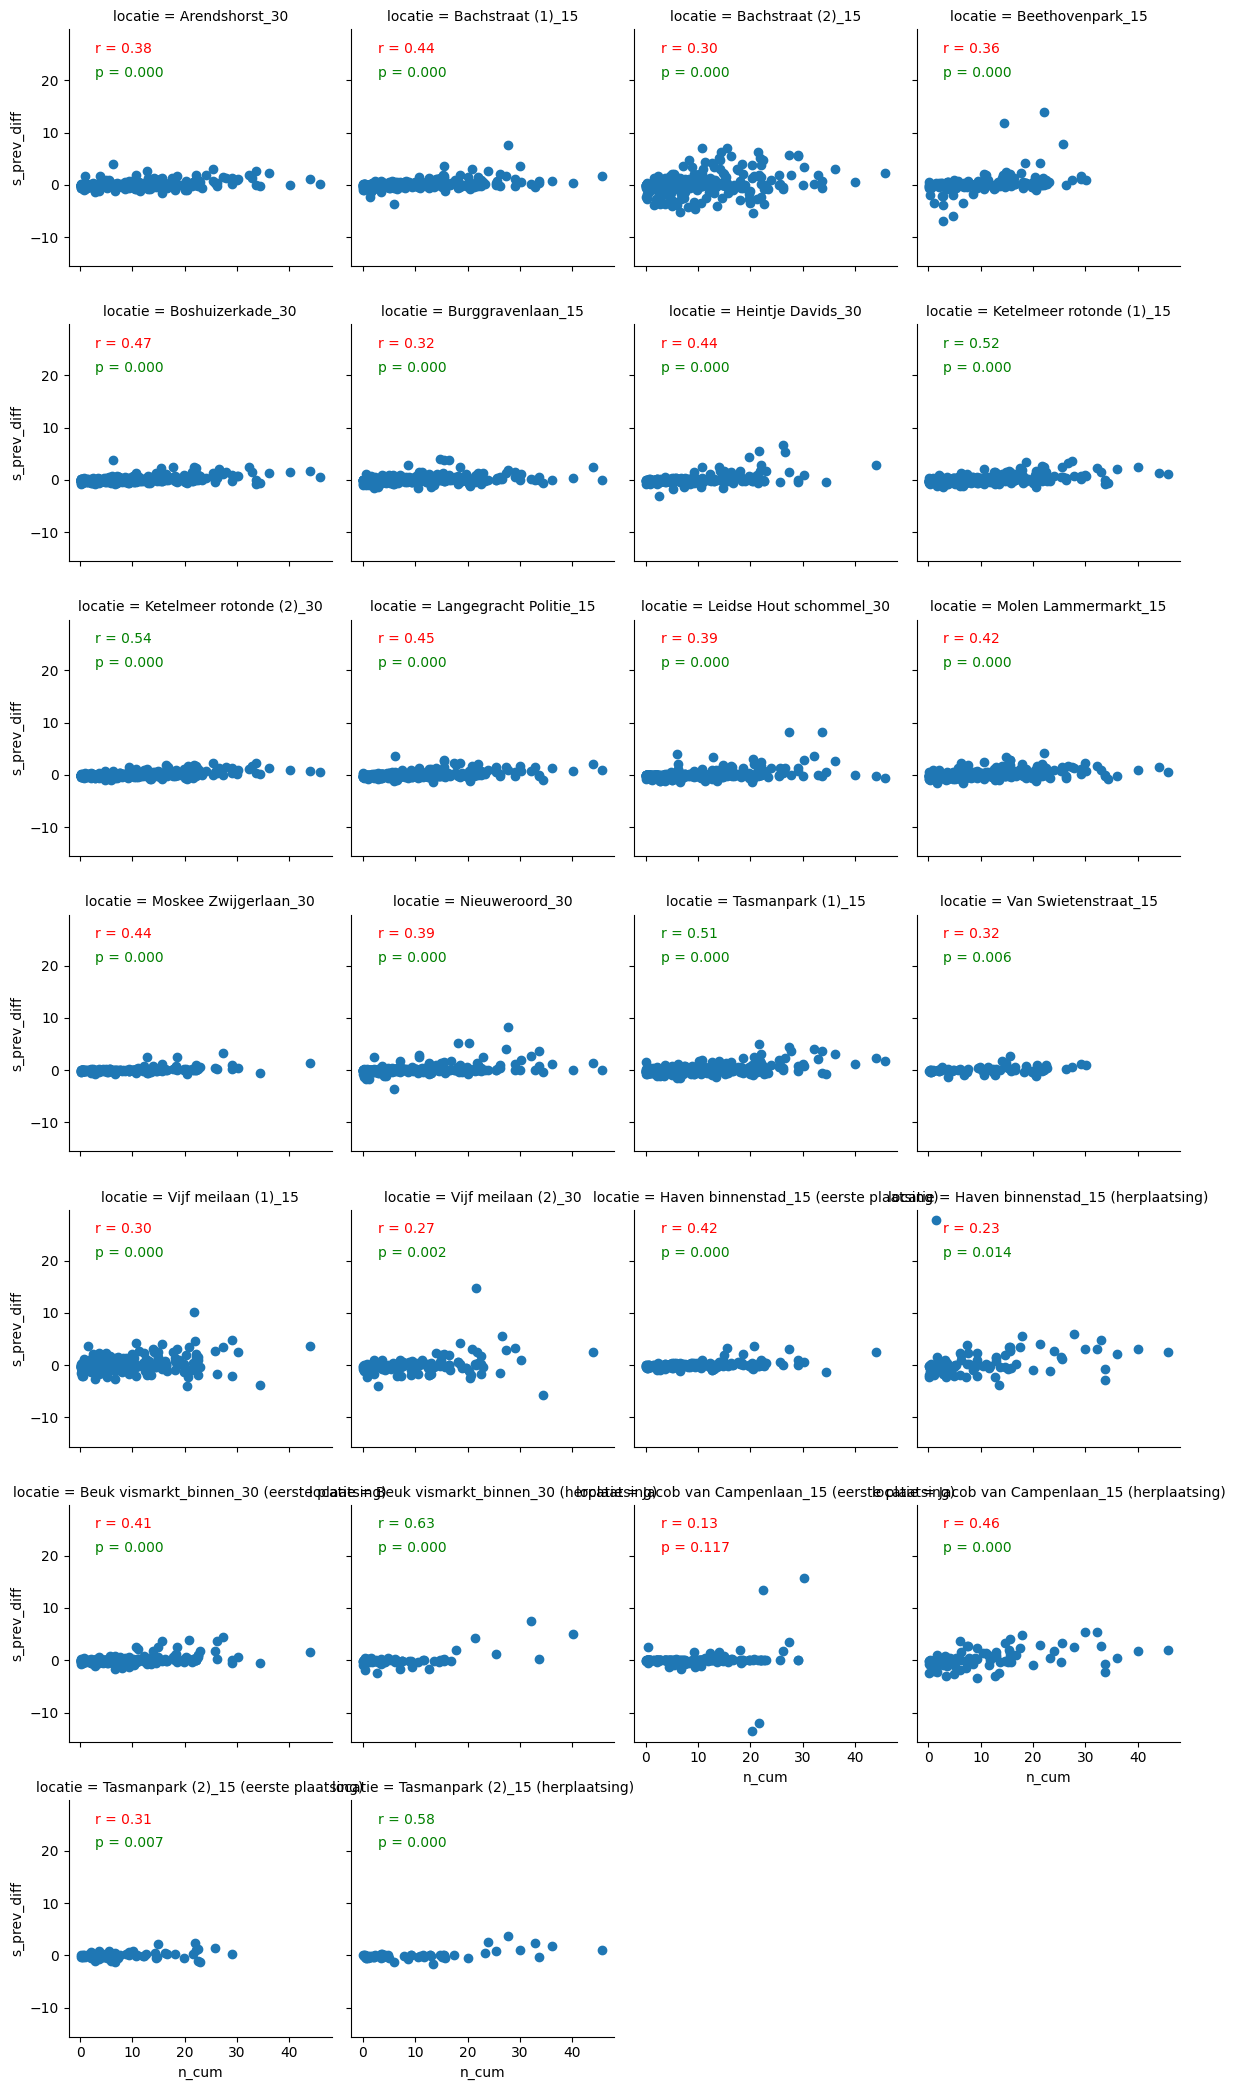

In [ ]:
measure = 's_prev_diff'
impact_on_col_lst = ['n_cum']

# Define custom scatterplot function
def scatterplot_with_corr_and_pval(x, y, **kwargs):
    # Calculate the correlation and p-value
    correlation, p_value = pearsonr(x, y)
    # Create scatterplot
    ax = plt.gca()
    ax.scatter(x, y, **kwargs)

    # Define colors based on correlation and p-value
    p_color = 'green' if p_value <= 0.05 else 'red'
    r_color = 'green' if abs(correlation) >= 0.5 else 'red'

    # Annotate with correlation coefficient and p-value
    ax.text(0.1, 0.9, f'r = {correlation:.2f}',
            transform=ax.transAxes, color=r_color)
    ax.text(0.1, 0.8, f'p = {p_value:.3f}',
            transform=ax.transAxes, color=p_color)

# Create a scatterplot matrix per location
for impact_on_col in impact_on_col_lst:
        df_neerslag = df[(df[impact_on_col] > 0) & (~df[impact_on_col].isna()) & (~df[measure].isna())]
        g = sns.FacetGrid(df_neerslag, col="locatie", col_wrap=4, height=3)
        # Create a scatterplot matrix per location

        print(f'impact of {impact_on_col} on {measure}')
        g = g.map(scatterplot_with_corr_and_pval, impact_on_col, measure)

# 5 Visualisaties - measures vs neerslag

In [ ]:
df_visual = df[df['datum'] > datetime(2024, 6, 1)].copy()
# df_visual = df.copy()
df_visual.sort_values(by=['locatie', 'datum'], inplace=True)
max_neerslag = df_visual['n'].max()

max_sensorwaarde = df_visual['s'].max()
fig = sensor_visual('gem_meetwaarde', df_visual, max_neerslag, max_sensorwaarde)
fig.show()

max_sensorwaarde = df_visual['s_min_max'].max()
fig = sensor_visual('s_min_max', df_visual, max_neerslag, max_sensorwaarde)
fig.show()

# max_sensorwaarde = df_visual['s_norm'].max()
# fig = sensor_visual('s_norm', df_visual, max_neerslag, max_sensorwaarde)
# fig.show()

c:\Users\JSpan\AppData\Local\anaconda3\envs\waterleiden\Lib\site-packages\_plotly_utils\basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\JSpan\AppData\Local\anaconda3\envs\waterleiden\Lib\site-packages\_plotly_utils\basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



c:\Users\JSpan\AppData\Local\anaconda3\envs\waterleiden\Lib\site-packages\_plotly_utils\basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\JSpan\AppData\Local\anaconda3\envs\waterleiden\Lib\site-packages\_plotly_utils\basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [ ]:
latest_values = df_visual.loc[df_visual.groupby('locatie')['datum'].idxmax()]
latest_values[['locatie','datum']].sort_values(by=['datum'], ascending=False)

,locatie,datum
883,Bachstraat (1)_15,2024-11-06
1340,Bachstraat (2)_15,2024-11-06
2076,Boshuizerkade_30,2024-11-06
2567,Burggravenlaan_15,2024-11-06
7428,Haven binnenstad_15 (herplaatsing),2024-11-06
8168,Jacob van Campenlaan_15 (herplaatsing),2024-11-06
3336,Ketelmeer rotonde (1)_15,2024-11-06
3827,Ketelmeer rotonde (2)_30,2024-11-06
4289,Langegracht Politie_15,2024-11-06
4780,Leidse Hout schommel_30,2024-11-06


# 6 Wanneer is er gesproeid?
Ik wil per locatie weten op welke dagen de gem_meetwaarde omhoog gaat ten opzichte van de vorige dag waarbij het diezelfde dag én de dag daarvoor er in totaal niet meer dan 2 mm regen is gevallen. Mijn aanname is dat er op dit moment dan wel gesproeid moet zijn.

In [ ]:
# Set the rainfall threshold
rainfall_threshold = 2

# Find the days where gem_waarde increased and the total rainfall was less than or equal to the threshold
df_gesproeid = df[(df['s_increase']) & (
    df['n_cum'] <= rainfall_threshold)]

# We only need the location, date, and gem_waarde for the final result
df_gesproeid = df_gesproeid[['locatie', 'datum', 'gem_meetwaarde']]

df_gesproeid

,locatie,datum,gem_meetwaarde
39,Arendshorst_30,2023-09-11,4.98750
44,Arendshorst_30,2023-09-16,4.88500
126,Arendshorst_30,2023-12-07,9.16800
127,Arendshorst_30,2023-12-08,9.21250
172,Arendshorst_30,2024-01-22,9.11500
...,...,...,...
8242,Tasmanpark (2)_15 (eerste plaatsing),2024-01-22,15.55000
8253,Tasmanpark (2)_15 (eerste plaatsing),2024-02-02,16.49000
8333,Tasmanpark (2)_15 (herplaatsing),2024-08-07,6.96625
8335,Tasmanpark (2)_15 (herplaatsing),2024-08-09,6.87625


# 7. Powerpoint presentatie
De powerpoint presentatie geeft een samenvatting van alle resultaten gevonden data analyse.

In [62]:
import importlib
import custom_functions.powerpoint  # Import the module

importlib.reload(custom_functions.powerpoint)  # Reload the module
from custom_functions.powerpoint import make_powerpoint  # Re-import the function

bool_make_powerpoint = True
measure = 'gem_meetwaarde'
folder_path_photo = 'C:/Users/JSpan/OneDrive - ilionx Group BV/03 Projects/5 - Gemeente Leiden/7 - 20241205 - Oplevering onderzoeksrapport/Sensor locaties documentatie/'
folder_path_image = 'C:/Users/JSpan/OneDrive - ilionx Group BV/03 Projects/5 - Gemeente Leiden/waterleiden/visuals/'
step_size_xaxis_days = 2

if bool_make_powerpoint:
    prs = make_powerpoint(df_visual, measure, folder_path_photo, folder_path_image,  step_size_xaxis_days)
    
    # Save the PowerPoint presentation
    prs.save("presentation.pptx")

NameError: name 'df_visual' is not defined

In [ ]:
# mapping = {loc: id for id, loc in enumerate(df['locatie'].unique())}

# df_export = pd.DataFrame(gemiddelde_daling).reset_index().merge(df_dim_sensor)[
#     ['locatie', 'perc_verschil_met_gister', 'diepte_plaatsing', 'leeftijd_plant', 'soort_plant', 'locatie_regio', 'extra_omschrijving']]

# df_export['locatie'] = df_export['locatie'].map(mapping)

# df_export.to_excel("./data/verdampingsnelheid.xlsx", index=False)

# inverse_mapping = {id: loc for loc, id in mapping.items()}
# df_export['locatie'] = df_export['locatie'].map(inverse_mapping)
# df_export

# # Plot the distribution of 'perc_verschil_met_gister'
# plt.figure(figsize=(10, 5))
# sns.histplot(df_export['perc_verschil_met_gister'], kde=True, bins=30)
# plt.title('Distribution of perc_verschil_met_gister')
# plt.show()

# # ANOVA for the remaining categorical variables
# categorical_vars = ['leeftijd_plant', 'soort_plant',
#                     'locatie_regio', 'extra_omschrijving', 'diepte_plaatsing']
# anova_pvalues = {}

# for var in categorical_vars:
#     categories = df_export[var].unique()
#     anova_results = f_oneway(
#         *(df_export['perc_verschil_met_gister'][df_export[var] == category] for category in categories))
#     anova_pvalues[var] = anova_results.pvalue

# anova_pvalues

# # Create boxplots for each categorical variable
# fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# for var, ax in zip(categorical_vars, axs.flatten()):
#     sns.boxplot(x=var, y='perc_verschil_met_gister', data=df_export, ax=ax)
#     ax.tick_params(axis='x', rotation=90)

# plt.tight_layout()
# plt.show()

# The distribution of 'perc_verschil_met_gister' appears to be approximately normal, 
# with most values centered around -0.02. There are no apparent outliers, which is good for our analysis.
# All these p-values are greater than 0.05, which means we fail to reject the null hypothesis that the means of 'perc_verschil_met_gister' 
# are the same across all categories for each of these variables. 
# In other words, it seems that none of these categorical variables have a significant impact on 'perc_verschil_met_gister'.